# A Learning Algorithm for Boltzmann Machines
**Authors:** David H. Ackley, Geoffrey E. Hinton, Terrence J. Sejnowski (1985, *Cognitive Science*)

# https://www.cs.toronto.edu/~fritz/absps/cogscibm.pdf

## Abstract
The paper introduces the Boltzmann Machine, a stochastic parallel network of binary units connected by symmetric weighted links, and derives a domain-independent learning algorithm grounded in statistical mechanics. The algorithm allows the network to construct an internal generative model matching the probability distribution of its training environment, using only locally available information for weight updates. The authors demonstrate the algorithm on several "encoder problem" tasks, showing that hidden units can discover efficient, distributed internal representations without prior coding conventions.

## Problems
- Massively parallel networks require (1) a search technique suitable for parallel hardware and (2) a method for choosing internal representations that make efficient use of preexisting connectivity.
- Standard constraint-satisfaction search techniques rely on deterministic gradient descent, which gets trapped in local minima that are not globally optimal.
- The classical "credit-assignment problem" prevents learning algorithms from being generalized beyond single-layer perceptrons to networks with hidden, nonlinear units: when a multilayer network errs, it is unclear which connection strengths are responsible.

## Proposed Solutions
- **Boltzmann Machine architecture:** units are binary (on/off), connected via symmetric bidirectional weighted links; a *true unit* absorbs thresholds as biases, giving the energy function
$$E = -\sum_{i<j} w_{ij} s_i s_j$$
- **Stochastic decision rule:** state transitions follow a Metropolis-like probabilistic update based on the energy gap $\Delta E_k = \sum_i w_{ki}s_i$, using a temperature parameter $T$:
$$p_k = \frac{1}{1+e^{-\Delta E_k/T}}$$
- **Simulated annealing** (gradually lowering $T$) allows the network to escape local energy minima and approach the global minimum, corresponding to thermal equilibrium and a Boltzmann distribution over global states.
- **Learning rule:** derived from the information-theoretic divergence $G$ between the environment-clamped and freely-running probability distributions over visible units, yielding a purely local weight-update rule:
$$\Delta w_{ij} = \epsilon (p_{ij} - p_{ij}')$$
where $p_{ij}$ is the co-occurrence probability of units $i,j$ under environmental clamping, and $p_{ij}'$ is the corresponding probability during free-running equilibrium.

## Purpose
To develop a general, biologically plausible, and mathematically tractable learning procedure that enables networks with hidden units to autonomously discover internal representations capturing high-order regularities in an environment, thereby solving the credit-assignment problem inherent to multilayer connectionist systems.

## Methodology
- **Network partition:** units are divided into *visible* units (clamped by the environment during training) and *hidden* units (never clamped, used to represent higher-order constraints).
- **Two-phase equilibrium estimation per learning cycle:**
  1. Clamp visible units to environmental vectors; anneal to equilibrium; estimate $p_{ij}$.
  2. Run the network freely (unclamped); anneal to equilibrium; estimate $p_{ij}'$.
- **Weight update:** increment/decrement each $w_{ij}$ by a fixed step according to the sign of $p_{ij}-p_{ij}'$.
- **Noisy clamping** technique (randomly flipping bits with small probability) prevents weights from diverging to infinity when only a subset of possible input patterns occur.
- **Benchmark task — "encoder problem":** two visible groups $V_1, V_2$ of $v$ units each, connected only through $h < v$ hidden units, must learn to communicate corresponding activation patterns through a bandwidth-limited bottleneck, requiring $h \geq \log_2 v$.
- Experiments conducted on 4-2-4, 4-3-4, 8-3-8, and 40-10-40 encoder configurations, with annealing schedules specified (e.g., $[2@20, 2@15, 2@12, 4@10]$).

## Results
- The 4-2-4 encoder reliably discovered a valid binary code across 250 trials, converging to a global minimum in a median of 110 learning cycles (max 1810).
- Learning proceeds in three observed phases: (1) formation of winner-take-all inhibition within each visible group, (2) development of positive hidden-to-visible weights establishing symmetric codes, (3) competitive "sorting out" of conflicting codes via lateral inhibition among similar codes.
- The 4-3-4 encoder (excess hidden capacity) converged to optimally spaced codes (Hamming distance ≥ 2) in a median of 270 cycles.
- The 8-3-8 encoder, with a much smaller solution-to-search-space ratio, found all 8 codes in only 16/20 simulations, requiring far more cycles (median 1570), illustrating that tasks with minimal spare capacity are harder to solve reliably.
- The larger 40-10-40 encoder achieved 98.6% completion accuracy, with performance improving sharply once "noisy clamping" was removed after sufficient training, and codes exhibited low similarity (cosine ≤ 0.73) confirming effective distributed coding.
- A gentler annealing schedule during testing (vs. training) reduced completion errors, revealing a speed/accuracy trade-off analogous to human reaction-time models.

## Conclusions
- The Boltzmann Machine demonstrates that a purely local, gradient-based learning rule can solve the credit-assignment problem for networks with hidden units, using only observable co-occurrence statistics at thermal equilibrium.
- The framework reconciles local and distributed representation debates: distributed representations correspond to energy minima, and the learning algorithm can construct favorable "energy landscapes" automatically.
- The model provides a biologically plausible alternative to symbolic message-passing schemes for inter-module communication, using shared low-bandwidth connections instead of dedicated symbolic channels.
- The algorithm performs best in domains with many acceptable (non-unique) solutions and sufficient spare network capacity; it becomes considerably slower when the solution space is narrow (e.g., the 8-3-8 case).
- The authors note the current algorithm is computationally slow and further work (parameter tuning, alternative estimation methods) is needed for scaling to larger networks, but the theoretical contribution establishes a mathematically principled connectionist learning framework.

# Mathematical and Statistical Content Summary
## "A Learning Algorithm for Boltzmann Machines" (Ackley, Hinton, Sejnowski, 1985)

## 1. Energy Function of a Global Configuration
$$E = -\sum_{i<j} w_{ij}\, s_i s_j + \sum_i \theta_i s_i$$

**Meaning:** Each possible on/off pattern of all units ("global configuration") is assigned a single number, its energy, analogous to physical systems. $w_{ij}$ is the connection strength between units $i$ and $j$, $s_i \in \{0,1\}$ is the state of unit $i$, and $\theta_i$ is a threshold. Low-energy configurations represent combinations of hypotheses that satisfy the network's constraints well; high-energy configurations represent poor, constraint-violating combinations. This equation is the foundation for defining "good" versus "bad" interpretations in the network.

## 2. Energy Gap for a Single Unit
$$\Delta E_k = \sum_i w_{ki}\, s_i - \theta_k$$

**Meaning:** This is the difference in total energy between having unit $k$ on versus off, computed only from local information (the states of neighboring units and $k$'s own weights/threshold). It tells a single unit how much the global energy would change if it flipped state, without needing global knowledge of the network.

## 3. Elimination of Thresholds via a "True Unit"
By introducing a permanently "on" bias unit, the threshold $\theta_i$ is absorbed into the weights (as $-\theta_i$), simplifying the equations to:
$$E = -\sum_{i<j} w_{ij}\, s_i s_j, \qquad \Delta E_k = \sum_i w_{ki}\, s_i$$

**Meaning:** A mathematical simplification—thresholds are treated as ordinary connection weights to a fictitious always-on unit, making all subsequent formulas cleaner and more uniform.

## 4. Stochastic (Metropolis-style) Update Rule
$$p_k = \frac{1}{1 + e^{-\Delta E_k / T}}$$

**Meaning:** Rather than deterministically switching to the lower-energy state, each unit turns on with a probability given by this logistic (sigmoid) function of its energy gap, scaled by a "temperature" $T$. This introduces controlled randomness ("noise"), allowing the network to occasionally accept energy-increasing moves and escape local minima—unlike simple deterministic gradient descent, which gets stuck. Higher $T$ flattens the curve (more randomness); lower $T$ sharpens it toward deterministic behavior.

## 5. Simulated Annealing
The temperature $T$ is gradually lowered over time (e.g., schedule $[2@20, 2@15, 2@12, 4@10]$ in the experiments).

**Meaning:** This is a statistical optimization strategy (borrowed from thermodynamics) in which the system first explores broadly at high temperature (ignoring small energy differences, finding the coarse structure of good solutions) and then refines its choice at low temperature (settling into a good, ideally global, energy minimum). This addresses the local-minima problem of pure gradient descent.

## 6. Boltzmann (Equilibrium) Distribution
$$\frac{P_\alpha}{P_\beta} = e^{-(E_\alpha - E_\beta)/T}$$

**Meaning:** After the network runs long enough at a given temperature, it reaches "thermal equilibrium," where the relative probability of being in any two global states depends only on the difference in their energies. This is the classical Boltzmann distribution from statistical mechanics, applied here to network states. It implies that the log-probability difference between two states equals their energy difference (at $T=1$), which is the key mathematical property exploited for learning.

## 7. Derivative of Log-Probability with Respect to Weights
$$\frac{\partial \ln P_\alpha}{\partial w_{ij}} = \frac{1}{T}\left[s_i^\alpha s_j^\alpha - p_{ij}\right]$$

**Meaning:** This shows how changing a single weight affects the probability of one particular global state $\alpha$. Because the energy is a linear function of the weights, this relationship is remarkably simple: it depends only on whether units $i,j$ are both on in that state versus their average joint on-probability $p_{ij}$ across the whole equilibrium distribution.

## 8. Information-Theoretic Divergence Measure (G)
$$G = \sum_\alpha P(V_\alpha)\, \ln \frac{P(V_\alpha)}{P'(V_\alpha)}$$

**Meaning:** This is the Kullback–Leibler divergence (relative entropy) between two probability distributions over the visible units' states: $P(V_\alpha)$, the distribution imposed by the environment (training data), and $P'(V_\alpha)$, the distribution the network produces when running freely without input. $G$ is always $\geq 0$ and equals zero exactly when the network's internal model perfectly matches the environment. It serves as the objective function to minimize during learning—essentially a measure of "how wrong" the network's generative model currently is. The authors note minimizing $G$ is mathematically equivalent to maximum likelihood estimation of the weights.

## 9. Gradient of G with Respect to Weights
$$\frac{\partial G}{\partial w_{ij}} = -\frac{1}{T}(p_{ij} - p_{ij}')$$

**Meaning:** This is the central mathematical result of the paper. It shows that the gradient of the global discrepancy measure $G$—normally very difficult to compute in nonlinear, cross-coupled networks—reduces to a remarkably simple, *local* quantity: the difference between two co-occurrence probabilities for units $i$ and $j$:
- $p_{ij}$: probability both units are on together when the environment clamps the visible units (the "driven" or "wake" phase).
- $p_{ij}'$: probability both units are on together when the network runs freely with no environmental input (the "free-running" or "sleep" phase).

## 10. Weight Update (Learning) Rule
$$\Delta w_{ij} = \epsilon (p_{ij} - p_{ij}')$$

**Meaning:** This is the practical gradient descent rule used to train the network: each weight is nudged in proportion to the difference between its clamped and free-running co-occurrence statistics, scaled by a learning rate $\epsilon$. Its major significance is that it requires **only locally observable information** (statistics about two connected units), even though it provably optimizes a *global* objective function ($G$) that depends on the entire network. This solves the credit-assignment problem: each connection can determine its own correct update without needing information about distant parts of the network.

In the simulations, a discretized version was used instead of the continuous gradient:
$$w_{ij} \leftarrow w_{ij} + \text{sign}(p_{ij} - p_{ij}') \times (\text{fixed step size, e.g., } 2)$$

**Meaning:** Rather than scaling the update by the exact magnitude of $(p_{ij}-p_{ij}')$, the authors used a fixed-size step in the appropriate direction. This is more robust to regions where $G$'s curvature varies sharply (steep "ravines"), avoiding divergent oscillations that a fixed learning rate $\epsilon$ might cause under standard steepest descent.

## 11. Concavity Property of G (No Hidden Units)
The paper states that when there are no hidden units, $G$-space is concave (viewed from above), guaranteeing that simple gradient descent will not get trapped in poor local minima.

**Meaning:** A theoretical guarantee: for the simplest case (visible units only), the optimization landscape has a single global optimum reachable by gradient descent. Adding hidden units breaks this guarantee (multiple local minima become possible, corresponding to different internal representations), motivating the use of noise/annealing during learning as well.

## 12. Encoder Problem Capacity Constraint
$$h \geq \log_2 v$$

**Meaning:** A simple information-theoretic bound: to allow $v$ distinct visible patterns to be losslessly communicated through $h$ hidden (bottleneck) units, the number of hidden units must be at least the base-2 logarithm of $v$ (since $h$ binary units can represent $2^h$ distinct codes). This defines the minimal "bandwidth" needed for perfect encoding and is used to size the encoder experiments (e.g., 4-2-4, 8-3-8, 40-10-40).

## 13. Appendix Derivation — Free-Running Visible Distribution
$$P'(V_\alpha) = \sum_\beta P'(V_\alpha \wedge H_\beta) = \frac{\sum_\beta e^{-E_{\alpha\beta}/T}}{\sum_{\lambda\mu} e^{-E_{\lambda\mu}/T}}$$

**Meaning:** Expresses the probability of a visible-unit state as the sum (marginalization) over all possible hidden-unit states $H_\beta$, using the Boltzmann distribution over the full network. This is the starting point for formally deriving the learning rule.

## 14. Conditional Probability Equivalence (Key Lemma)
$$P'(H_\beta \mid V_\alpha) = P(H_\beta \mid V_\alpha)$$

**Meaning:** This equality states that, given a specific visible-unit pattern, the probability distribution over hidden-unit states is the same whether that visible pattern was externally clamped or arose naturally from free-running equilibrium. This is a crucial equilibrium property (a consequence of detailed balance) that allows the clamped and free-running statistics to be meaningfully compared and combined in the derivation of $\partial G/\partial w_{ij}$.

## 15. Input-Output Formulation of G
$$G = \sum_{\alpha\beta} P(I_\alpha \wedge O_\beta) \ln \frac{P(O_\beta \mid I_\alpha)}{P'(O_\beta \mid I_\alpha)}$$

**Meaning:** An alternative version of the divergence measure for supervised (input/output) learning tasks, where visible units are split into an input set $I$ and output set $O$. During training both are clamped; during testing only $I$ is clamped and $O$/hidden units free-run. The same gradient formula $\partial G/\partial w_{ij} = -\frac{1}{T}(p_{ij}-p_{ij}')$ applies, showing the learning rule generalizes naturally from unsupervised generative modeling to supervised prediction tasks.

## Summary Table

| Concept | Role in Paper |
|---|---|
| Energy function $E$ | Defines quality/cost of a network configuration |
| Energy gap $\Delta E_k$ | Local signal for whether a unit should turn on |
| Logistic update rule $p_k$ | Stochastic decision rule enabling escape from local minima |
| Simulated annealing | Search strategy trading exploration vs. exploitation via temperature |
| Boltzmann distribution | Statistical-mechanics law governing equilibrium state probabilities |
| Divergence $G$ | Global objective function measuring model-environment mismatch |
| Gradient $\partial G/\partial w_{ij}$ | Shows learning gradient reduces to local co-occurrence statistics |
| Weight update $\Delta w_{ij}$ | Practical, biologically plausible learning rule (solves credit assignment) |
| Encoder capacity bound $h \geq \log_2 v$ | Sets minimum hidden-unit requirement for benchmark tasks |

# Structured Analysis: Problems, Limitations, and Proposed Solutions
## "A Learning Algorithm for Boltzmann Machines" (Ackley, Hinton, Sejnowski, 1985)

| # | Key Problem / Research Gap | How This Limited Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Massively parallel networks need a search technique compatible with distributed, local hardware connections | Sequential search algorithms do not exploit parallel hardware efficiently; existing parallel approaches (e.g., surface interpolation models) required problem-specific architectures determined in advance | Introduces a stochastic, asynchronous unit-update rule based on statistical mechanics, allowing parallel constraint satisfaction search without pre-specified problem structure |
| 2 | Constraint-satisfaction searches conventionally rely on "strong" constraints that must always hold | Strong-constraint methods (e.g., Waltz, 1975) are unsuitable for domains like perceptual interpretation, where even optimal solutions violate some constraints | Formulates the network using "weak" constraints with associated costs, where total violation cost (energy) is minimized rather than requiring strict satisfaction |
| 3 | Deterministic gradient-descent-style relaxation (e.g., Hopfield networks) gets trapped in local energy minima | Hopfield-style networks are effective for associative memory (falling into the nearest minimum is desirable) but inadequate for search tasks requiring the true global optimum | Adopts a stochastic Metropolis-style decision rule with a temperature parameter, combined with simulated annealing, enabling escape from local minima toward the global minimum |
| 4 | The credit-assignment problem: no general method existed to determine which weights in a multilayer, nonlinear network are responsible for errors | This limitation caused the historical demise of perceptron-based learning (Minsky & Papert, 1968); learning could not be generalized beyond single-layer decision units to networks with hidden units | Derives a mathematically simple relationship between global network probability (via the Boltzmann distribution) and individual connection weights, enabling locally computable weight updates that provably optimize a global objective |
| 5 | No general, domain-independent rule existed for training networks to model an environment's underlying probability distribution, especially with hidden units | Prior systems required either fully pre-specified architectures or environment-provided target probabilities for complete global states, removing the need for the network to discover representations itself | Defines an information-theoretic discrepancy measure $G$ (asymmetric divergence) between the environment's distribution and the network's free-running distribution, and shows its gradient reduces to a simple local statistic |
| 6 | Networks lacked a principled way to construct internal ("hidden") representations for regularities not expressible via pairwise constraints among visible units alone (e.g., parity constraints) | Purely visible-unit networks cannot represent higher-order dependencies; without hidden units, complex environmental regularities (e.g., 3-way parity) cannot be captured | Introduces hidden units that are never directly clamped by the environment; the learning rule allows these units to autonomously discover distributed codes that reduce higher-order constraints to pairwise ones |
| 7 | Estimating the objective function's exact gradient is computationally infeasible for most cross-coupled nonlinear networks | Standard backpropagation-style or closed-form gradient computation is intractable in recurrent, symmetric, stochastic networks | Exploits the equilibrium property of the Boltzmann distribution to derive a closed-form, locally observable expression for $\partial G/\partial w_{ij} = -\frac{1}{T}(p_{ij}-p_{ij}')$, avoiding the need for global gradient computation |
| 8 | Networks that specify zero-probability patterns implicitly require infinitely large weights, which is numerically and biologically implausible | Prior generative frameworks did not address how to avoid pathological weight growth when only a subset of input patterns should ever occur | Introduces a "noisy clamping" technique that occasionally perturbs input vectors, ensuring all patterns retain nonzero probability and preventing unbounded weight growth |
| 9 | Existing accounts of symbolic communication between parallel modules (Feldman & Ballard, 1982) faced a trade-off between sequential bus-based messaging (biologically implausible, slow) and dedicated per-concept hardware pathways (inflexible, requires a priori wiring) | Neither implementation could plausibly explain how new codes for new concepts could emerge without pre-established wiring or symbolic protocols | Demonstrates via the "encoder problem" that the learning algorithm can autonomously discover shared, distributed, low-bandwidth codes for communicating information between modules, without any a priori coding convention |
| 10 | Absence of empirical validation for whether a locally-computed learning rule can scale to nontrivial network sizes and tasks | Theoretical learning proposals lacked demonstrations that internal representations converge reliably and efficiently in practice | Provides simulation results on 4-2-4, 4-3-4, 8-3-8, and 40-10-40 encoder problems, empirically showing convergence to near-optimal, well-spaced distributed codes, though noting the algorithm remains computationally slow for large or tightly constrained solution spaces |

In [1]:
# =====================================================================================
# Educational Replication of:
# "A Learning Algorithm for Boltzmann Machines"
# Ackley, Hinton, and Sejnowski (1985)
#
# This notebook implements a SMALL, FULLY-CONNECTED, class-conditional Boltzmann
# Machine trained with the paper's original local, correlation-based learning rule
# (positive phase minus negative phase co-activation statistics), NOT with
# backpropagation, autodiff, contrastive divergence, or a Restricted Boltzmann
# Machine architecture.
#
# NOTE: This is a deliberately simplified, EDUCATIONAL approximation. The original
# algorithm requires very long annealing/Gibbs-sampling runs to reach true thermal
# equilibrium. Here we drastically shorten the annealing schedule, dataset size,
# and epoch count so that the ideas remain visible in a reasonable Colab runtime.
# The code below is NOT executed -- it is provided ready-to-run.
# =====================================================================================

# !pip -q install datasets scikit-learn

import io
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset

from datasets import load_dataset

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import confusion_matrix

from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# =====================================================================================
# 0. GLOBAL REPRODUCIBILITY AND DEVICE
# =====================================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# =====================================================================================
# 1. WHITE VISUAL THEME (applied globally via rcParams)
# =====================================================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "legend.labelcolor": "black",
    "grid.color": "#d9d9d9",
    "axes.grid": True,
    "grid.alpha": 0.6,
})


def display_figure(fig):
    """
    Renders a matplotlib figure inline using an in-memory PNG buffer.
    We intentionally avoid plt.show()/plt.savefig()/fig.show() and instead use
    fig.savefig() into a BytesIO buffer, as required for Colab-safe inline display.
    """
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    buf.close()
    plt.close(fig)

In [4]:
# =====================================================================================
# 2. WHY THE INPUT MUST BE SIMPLIFIED
# =====================================================================================
# A fully-connected, symmetric Boltzmann Machine has O(N^2) weights. If we tried to
# use full 64x64 RGB pixels directly as visible units, N would be enormous
# (64*64*3 = 12288 visible units alone), making the weight matrix (~150 million
# entries) and the required Gibbs sampling completely impractical for education.
#
# Instead we compress every CIFAR-10 image down to a tiny 8x8 BINARY grayscale
# "sketch" (64 binary units). This keeps the entire network (image + label + hidden
# units = 90 units, 90x90 weight matrix) small enough to simulate with plain
# Python/PyTorch loops on CPU or a small GPU, while still preserving every core
# mechanic described in the paper (binary units, symmetric weights, energy,
# stochastic updates, clamping, annealing, local learning).

NUM_IMAGE_UNITS = 64
NUM_LABEL_UNITS = 10
NUM_HIDDEN_UNITS = 16
NUM_UNITS = NUM_IMAGE_UNITS + NUM_LABEL_UNITS + NUM_HIDDEN_UNITS  # 90

# Global state vector layout (per sample):
#   indices [0:64)   -> binary image-visible units  ("what the retina sees")
#   indices [64:74)  -> binary one-hot label-visible units ("which class is present")
#   indices [74:90)  -> binary hidden units (never clamped; learn internal codes
#                        that capture regularities/correlations between image and label)
IMAGE_SLICE = slice(0, NUM_IMAGE_UNITS)
LABEL_SLICE = slice(NUM_IMAGE_UNITS, NUM_IMAGE_UNITS + NUM_LABEL_UNITS)
HIDDEN_SLICE = slice(NUM_IMAGE_UNITS + NUM_LABEL_UNITS, NUM_UNITS)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [5]:
# =====================================================================================
# 3. NETWORK ARCHITECTURE: SYMMETRIC WEIGHT MATRIX AND BIAS VECTOR
# =====================================================================================
# Every unit is connected to every other unit through a SINGLE symmetric weight
# matrix W (W_ij = W_ji), which is the defining structural property of a Boltzmann
# Machine (unlike a Restricted Boltzmann Machine, which only allows visible<->hidden
# connections). Self-connections (the diagonal of W) are meaningless -- a unit does
# not "input" to itself -- so the diagonal is forced to zero. Biases act as
# trainable thresholds (they are mathematically equivalent to a weight from a
# permanently "on" true unit, as described in the paper).

def init_boltzmann_params(num_units, device, scale=0.01):
    W = torch.randn(num_units, num_units, device=device) * scale
    W = (W + W.T) / 2.0          # force symmetry: W_ij = W_ji
    W.fill_diagonal_(0.0)        # no self-connections
    b = torch.zeros(num_units, device=device)  # unit biases / thresholds
    return W, b


W, b = init_boltzmann_params(NUM_UNITS, DEVICE)


def enforce_weight_constraints(W):
    """Re-symmetrize W and zero its diagonal after every update (numerical safety)."""
    with torch.no_grad():
        W.copy_((W + W.T) / 2.0)
        W.fill_diagonal_(0.0)
    return W

In [6]:
# =====================================================================================
# 4. ENERGY FUNCTION
# =====================================================================================
# The energy of a global configuration s is:
#     E(s) = -1/2 * s^T W s  -  b^T s
# Low energy = a configuration that satisfies many weak pairwise constraints
# (positively-weighted co-active pairs, negatively-weighted pairs kept apart).
# The network's stochastic dynamics are built to prefer low-energy states.

@torch.no_grad()
def compute_energy(states, W, b):
    """
    states: [B, N] binary tensor (batch of global configurations)
    Returns: [B] tensor of energies, one per sample.
    """
    quad = torch.sum((states @ W) * states, dim=1)  # s^T W s
    lin = states @ b                                 # b^T s
    energy = -0.5 * quad - lin
    return energy

In [7]:
# =====================================================================================
# 5. STOCHASTIC UNIT UPDATE (ASYNCHRONOUS GIBBS SAMPLING)
# =====================================================================================
# Each unit i receives a total input a_i = b_i + sum_j W_ij * s_j from every other
# unit (its neighbors' current states weighted by connection strength). Rather than
# deterministically turning "on" whenever a_i > 0 (which would get stuck in local
# energy minima), the paper uses a STOCHASTIC decision rule: the unit turns on with
# probability sigmoid(a_i / T). Temperature T controls randomness: high T ~ nearly
# coin-flip behavior (broad exploration); low T ~ nearly deterministic (exploitation
# of low-energy configurations). Units are updated ONE AT A TIME in random order
# (asynchronous Gibbs sampling), and clamped units are never touched.

@torch.no_grad()
def update_single_unit(states, clamp_mask, W, b, unit_index, T):
    """
    Updates unit `unit_index` for every sample in the batch simultaneously
    (this is still "one unit at a time" in the sense that only ONE unit index
    is resampled per call, matching the paper's asynchronous update rule --
    we simply vectorize this single-unit update across the batch dimension
    for computational efficiency).
    """
    a_i = b[unit_index] + states @ W[:, unit_index]   # [B] total input to unit i
    p_i = torch.sigmoid(a_i / T)                       # P(s_i = 1)
    sampled = torch.bernoulli(p_i)                     # stochastic sample, NOT thresholding
    can_update = ~clamp_mask[:, unit_index]             # respect clamped-unit mask
    states[:, unit_index] = torch.where(can_update, sampled, states[:, unit_index])
    return states


@torch.no_grad()
def gibbs_sweep(states, clamp_mask, W, b, T):
    """One full sweep = every unit gets one chance to update, in random order."""
    order = torch.randperm(states.shape[1])
    for i in order.tolist():
        states = update_single_unit(states, clamp_mask, W, b, i, T)
    return states


@torch.no_grad()
def run_gibbs_sweeps(states, clamp_mask, W, b, T, n_sweeps):
    for _ in range(n_sweeps):
        states = gibbs_sweep(states, clamp_mask, W, b, T)
    return states


@torch.no_grad()
def run_annealing_schedule(states, clamp_mask, W, b, schedule):
    """
    Runs a full simulated-annealing schedule: a list of (temperature, n_sweeps)
    pairs, executed in order from HIGH temperature to LOW temperature.
    """
    for T, n_sweeps in schedule:
        states = run_gibbs_sweeps(states, clamp_mask, W, b, T, n_sweeps)
    return states

In [8]:
# =====================================================================================
# 6. TEMPERATURE AND ANNEALING SCHEDULE
# =====================================================================================
# High temperature early on lets the network explore broadly and escape POOR local
# energy minima (this is the "noise" mechanism from Section 2.2 of the paper).
# As temperature is lowered, the network increasingly commits to low-energy
# ("good") configurations. This schedule is heavily SHORTENED relative to the
# original paper (which used many more/longer stages) purely for educational
# runtime reasons -- a real Boltzmann Machine anneal is far slower.
annealing_schedule = [
    (4.0, 2),   # high T: broad, noisy exploration
    (2.0, 2),   # cooling: structure starts to emerge
    (1.5, 2),   # further cooling: settling toward low-energy states
    (1.0, 4),   # near-final T: statistics are collected close to equilibrium
]

STATISTICS_TEMPERATURE = 1.0  # temperature at which final co-activation stats are read

In [ ]:
# =====================================================================================
# 7. DATASET -- HUGGINGFACE CIFAR-10 ONLY
# =====================================================================================

ds = load_dataset("uoft-cs/cifar10")


class HFCIFAR10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split as a standard PyTorch Dataset."""

    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = item["label"]
        return img_tensor, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

full_train_dataset = HFCIFAR10Dataset(ds["train"], train_transform)
full_test_dataset = HFCIFAR10Dataset(ds["test"], test_transform)

In [10]:
# =====================================================================================
# 8. IMAGE -> 64 BINARY UNITS CONVERSION
# =====================================================================================

def to_binary_image_units(img_batch, mean=IMAGENET_MEAN, std=IMAGENET_STD, threshold=0.5):
    """
    Converts a batch of normalized RGB tensors [B, 3, 64, 64] into a batch of
    64 binary image-visible units [B, 64], following:
      1. Un-normalize back to [0, 1] pixel range.
      2. Convert to grayscale (standard luminance weights).
      3. Adaptive-average-pool down to an 8x8 "sketch".
      4. Flatten to 64 values.
      5. Binarize with a fixed threshold of 0.5.
    """
    mean_t = torch.tensor(mean, device=img_batch.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std, device=img_batch.device).view(1, 3, 1, 1)
    img = img_batch * std_t + mean_t          # undo normalization -> approx [0,1]
    img = torch.clamp(img, 0.0, 1.0)

    # standard luminance-weighted grayscale conversion
    gray = 0.299 * img[:, 0] + 0.587 * img[:, 1] + 0.114 * img[:, 2]  # [B, 64, 64]
    gray = gray.unsqueeze(1)  # [B, 1, 64, 64]

    pooled = F.adaptive_avg_pool2d(gray, (8, 8))   # [B, 1, 8, 8]
    flat = pooled.view(pooled.shape[0], -1)         # [B, 64]

    binary = (flat > threshold).float()
    return binary


def to_one_hot_labels(labels, num_classes=NUM_LABEL_UNITS):
    return F.one_hot(labels, num_classes=num_classes).float()

In [11]:
# =====================================================================================
# 9. SUBSETS AND DATA LOADERS
# =====================================================================================

TRAIN_SUBSET_SIZE = 2000
TEST_SUBSET_SIZE = 400

train_subset = Subset(full_train_dataset, list(range(TRAIN_SUBSET_SIZE)))
test_subset = Subset(full_test_dataset, list(range(TEST_SUBSET_SIZE)))

BATCH_SIZE = 64
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=PIN_MEMORY
)

In [12]:
# =====================================================================================
# 10. DATA SANITY CHECK
# =====================================================================================

sample_imgs, sample_labels = next(iter(train_loader))
sample_imgs = sample_imgs.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

sample_bin = to_binary_image_units(sample_imgs)

print("===== DATA SANITY CHECK =====")
print(f"Number of training samples (subset): {len(train_subset)}")
print(f"Number of test samples (subset):     {len(test_subset)}")
print(f"Original image-batch shape:          {tuple(sample_imgs.shape)}")
print(f"Binary image-feature shape:          {tuple(sample_bin.shape)}")
print(f"Binary feature min/max:              {sample_bin.min().item()} / {sample_bin.max().item()}")
print(f"Label range:                         {sample_labels.min().item()} - {sample_labels.max().item()}")
print(f"First 8 integer labels:              {sample_labels[:8].tolist()}")
print(f"First 8 class names:                 {[class_names[l] for l in sample_labels[:8].tolist()]}")
print(f"Total Boltzmann Machine units:       {NUM_UNITS} "
      f"({NUM_IMAGE_UNITS} image + {NUM_LABEL_UNITS} label + {NUM_HIDDEN_UNITS} hidden)")

assert torch.all((sample_bin == 0) | (sample_bin == 1)), "Binary image units must be strictly 0/1"
assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9, "Labels must be in [0, 9]"
assert torch.allclose(W, W.T), "W must be symmetric"
assert torch.all(torch.diagonal(W) == 0), "Diagonal of W must be zero"
print("All sanity assertions passed.\n")

===== DATA SANITY CHECK =====
Number of training samples (subset): 2000
Number of test samples (subset):     400
Original image-batch shape:          (64, 3, 64, 64)
Binary image-feature shape:          (64, 64)
Binary feature min/max:              0.0 / 1.0
Label range:                         0 - 9
First 8 integer labels:              [4, 1, 6, 4, 7, 3, 4, 8]
First 8 class names:                 ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']
Total Boltzmann Machine units:       90 (64 image + 10 label + 16 hidden)
All sanity assertions passed.



In [13]:
# =====================================================================================
# 11. TRAINING CONFIGURATION
# =====================================================================================
# WARNING: The original Boltzmann Machine learning algorithm (Ackley, Hinton &
# Sejnowski, 1985) is computationally very slow -- equilibrium sampling via
# simulated annealing must be repeated for BOTH a positive (data-clamped) phase
# and a negative (free-running) phase on EVERY training example. Five epochs on a
# tiny 2000-image subset with a heavily shortened annealing schedule is only an
# EDUCATIONAL DEMONSTRATION of the mechanics described in the paper, not a
# competitive image classifier.

NUM_EPOCHS = 5
LEARNING_RATE = 0.02
WEIGHT_CLIP = 3.0
BIAS_CLIP = 3.0

In [14]:
# =====================================================================================
# 12. TWO-PHASE LEARNING RULE (POSITIVE PHASE / NEGATIVE PHASE)
# =====================================================================================
# POSITIVE PHASE ("wake"/data phase): image units and label units are CLAMPED to a
# real training example; hidden units are left free to settle via annealed Gibbs
# sampling. This lets hidden units discover which internal ("hidden") code
# correlates with which image/label combination.
#
# NEGATIVE PHASE ("sleep"/free-running phase): NOTHING is clamped; the whole
# network free-runs via annealed Gibbs sampling from a random start, producing
# samples from the network's own current generative model of the environment.
#
# The learning rule (paper Eq. 10) says: increase w_ij if two units are co-active
# MORE OFTEN in the positive (data-driven) phase than in the negative
# (free-running) phase, and decrease w_ij otherwise. This is a purely LOCAL
# statistic -- each connection only needs to know about the two units it
# connects -- yet it provably performs gradient descent on a GLOBAL measure (G)
# of how well the network's internal model matches the training data
# distribution.

@torch.no_grad()
def positive_phase(image_bin, label_onehot, W, b, schedule):
    B = image_bin.shape[0]
    hidden_init = torch.bernoulli(torch.full((B, NUM_HIDDEN_UNITS), 0.5, device=DEVICE))
    states = torch.cat([image_bin, label_onehot, hidden_init], dim=1)

    clamp_mask = torch.zeros(B, NUM_UNITS, dtype=torch.bool, device=DEVICE)
    clamp_mask[:, IMAGE_SLICE] = True   # image units clamped to data
    clamp_mask[:, LABEL_SLICE] = True   # label units clamped to data
    # hidden units remain unclamped (free to settle)

    states = run_annealing_schedule(states, clamp_mask, W, b, schedule)
    # collect final activations at the statistics temperature (already the last
    # stage of the annealing schedule)
    corr = (states.T @ states) / B          # pairwise co-activation statistic p_ij
    mean_act = states.mean(dim=0)           # per-unit mean activation
    energy = compute_energy(states, W, b).mean()
    return states, corr, mean_act, energy


@torch.no_grad()
def negative_phase(batch_size, W, b, schedule):
    states = torch.bernoulli(torch.full((batch_size, NUM_UNITS), 0.5, device=DEVICE))
    clamp_mask = torch.zeros(batch_size, NUM_UNITS, dtype=torch.bool, device=DEVICE)
    # nothing is clamped: the network free-runs and generates its own samples

    states = run_annealing_schedule(states, clamp_mask, W, b, schedule)
    corr = (states.T @ states) / batch_size    # pairwise co-activation statistic p_ij'
    mean_act = states.mean(dim=0)
    energy = compute_energy(states, W, b).mean()
    return states, corr, mean_act, energy


@torch.no_grad()
def boltzmann_weight_update(W, b, pos_corr, neg_corr, pos_mean, neg_mean, lr):
    """
    Local, correlation-based learning rule (paper Eq. 10):
        delta_W_ij = lr * (p_ij - p_ij')
        delta_b_i  = lr * (mean_i_positive - mean_i_negative)
    NOTE: this is NOT gradient descent via autodiff, NOT contrastive divergence,
    and NOT backpropagation -- it is the original local statistic-comparison rule.
    """
    dW = lr * (pos_corr - neg_corr)
    dW = (dW + dW.T) / 2.0     # keep symmetric
    dW.fill_diagonal_(0.0)     # no self-connections

    db = lr * (pos_mean - neg_mean)

    W.add_(dW)
    b.add_(db)

    enforce_weight_constraints(W)
    W.clamp_(-WEIGHT_CLIP, WEIGHT_CLIP)
    b.clamp_(-BIAS_CLIP, BIAS_CLIP)

    update_magnitude = dW.abs().mean().item()
    return W, b, update_magnitude

In [15]:
# =====================================================================================
# 13. CLASSIFICATION PIPELINE (image units clamped, label units read out)
# =====================================================================================
# To classify an image: clamp only the 64 image-visible units, leave the 10 label
# units and 16 hidden units free, run the annealing schedule, and then read the
# label units' activation levels. This is NOT a calibrated softmax probability --
# it is a sampling-based activation estimate from a stochastic network, so we
# average several Gibbs sweeps at T = 1.0 to reduce sampling noise before picking
# the label unit with the highest mean activation.

@torch.no_grad()
def classify_batch(image_bin, W, b, schedule, n_readout_sweeps=5):
    B = image_bin.shape[0]
    label_init = torch.bernoulli(torch.full((B, NUM_LABEL_UNITS), 0.1, device=DEVICE))
    hidden_init = torch.bernoulli(torch.full((B, NUM_HIDDEN_UNITS), 0.5, device=DEVICE))
    states = torch.cat([image_bin, label_init, hidden_init], dim=1)

    clamp_mask = torch.zeros(B, NUM_UNITS, dtype=torch.bool, device=DEVICE)
    clamp_mask[:, IMAGE_SLICE] = True  # only image units clamped

    states = run_annealing_schedule(states, clamp_mask, W, b, schedule)

    # Average sampled label-unit activations over several extra sweeps at T=1.0
    # to approximate an "activation probability" read-out (not a true softmax).
    label_accum = torch.zeros(B, NUM_LABEL_UNITS, device=DEVICE)
    for _ in range(n_readout_sweeps):
        states = gibbs_sweep(states, clamp_mask, W, b, STATISTICS_TEMPERATURE)
        label_accum += states[:, LABEL_SLICE]
    label_scores = label_accum / n_readout_sweeps

    confidences, predicted = label_scores.max(dim=1)
    predicted_names = [class_names[p] for p in predicted.tolist()]
    return predicted, predicted_names, label_scores, confidences, states

In [16]:
# =====================================================================================
# 14. RECONSTRUCTION AND COMPLETION (pattern completion demonstration)
# =====================================================================================
# We hide the RIGHT HALF of each 8x8 binary "sketch" (columns 4-7 -> flattened
# indices), clamp only the LEFT HALF plus (optionally) the correct label, and let
# the network fill in the missing pixels via annealed Gibbs sampling. This
# directly demonstrates the paper's claim that a Boltzmann Machine can complete
# partial patterns by settling into a low-energy configuration consistent with
# whatever IS clamped.

def build_right_half_mask():
    """8x8 grid, hide right half (columns 4-7) -> boolean mask over 64 image units."""
    grid = np.zeros((8, 8), dtype=bool)
    grid[:, 4:] = True  # True = hidden/free (right half)
    return torch.tensor(grid.flatten(), device=DEVICE)


RIGHT_HALF_HIDDEN_MASK = build_right_half_mask()  # True where units are FREE (not clamped)


@torch.no_grad()
def reconstruct_batch(image_bin, label_onehot, W, b, schedule, clamp_label=True):
    B = image_bin.shape[0]
    hidden_init = torch.bernoulli(torch.full((B, NUM_HIDDEN_UNITS), 0.5, device=DEVICE))
    states = torch.cat([image_bin.clone(), label_onehot.clone(), hidden_init], dim=1)

    clamp_mask = torch.zeros(B, NUM_UNITS, dtype=torch.bool, device=DEVICE)
    image_clamp = ~RIGHT_HALF_HIDDEN_MASK  # left half clamped, right half free
    clamp_mask[:, IMAGE_SLICE] = image_clamp.unsqueeze(0).expand(B, -1)
    if clamp_label:
        clamp_mask[:, LABEL_SLICE] = True

    # randomize the hidden (right-half) pixels before sampling, so the network
    # must genuinely "complete" the pattern rather than trivially keep the answer
    states[:, IMAGE_SLICE][:, RIGHT_HALF_HIDDEN_MASK] = torch.bernoulli(
        torch.full((B, RIGHT_HALF_HIDDEN_MASK.sum().item()), 0.5, device=DEVICE)
    )

    reconstructed = run_annealing_schedule(states, clamp_mask, W, b, schedule)

    unclamped_pixels = RIGHT_HALF_HIDDEN_MASK
    error = (reconstructed[:, IMAGE_SLICE][:, unclamped_pixels] !=
             image_bin[:, unclamped_pixels]).float().mean().item()
    return reconstructed, error

In [17]:
# =====================================================================================
# 15. TRAINING LOOP
# =====================================================================================

history = {
    "pos_energy": [], "neg_energy": [], "energy_gap": [],
    "pos_stat_mag": [], "neg_stat_mag": [], "weight_update_mag": [],
    "reconstruction_error": [], "train_acc": [], "val_acc": [],
    "per_class_acc": [], "mean_hidden_activation": [], "mean_state_activation": [],
}

final_val_predictions = []
final_val_labels = []
final_val_confidences_correct = []
final_val_confidences_incorrect = []
final_pos_energy_samples = []
final_neg_energy_samples = []

print("===== TRAINING (educational, shortened annealing schedule) =====")
for epoch in range(NUM_EPOCHS):
    epoch_pos_energy, epoch_neg_energy = [], []
    epoch_pos_stat, epoch_neg_stat = [], []
    epoch_update_mag = []
    epoch_recon_err = []
    epoch_hidden_act, epoch_state_act = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        image_bin = to_binary_image_units(imgs)
        label_onehot = to_one_hot_labels(labels)

        # ---- POSITIVE PHASE (data-clamped) ----
        pos_states, pos_corr, pos_mean, pos_energy = positive_phase(
            image_bin, label_onehot, W, b, annealing_schedule
        )

        # ---- NEGATIVE PHASE (free-running) ----
        neg_states, neg_corr, neg_mean, neg_energy = negative_phase(
            imgs.shape[0], W, b, annealing_schedule
        )

        # ---- LOCAL WEIGHT UPDATE ----
        W, b, update_mag = boltzmann_weight_update(
            W, b, pos_corr, neg_corr, pos_mean, neg_mean, LEARNING_RATE
        )

        epoch_pos_energy.append(pos_energy.item())
        epoch_neg_energy.append(neg_energy.item())
        epoch_pos_stat.append(pos_corr.abs().mean().item())
        epoch_neg_stat.append(neg_corr.abs().mean().item())
        epoch_update_mag.append(update_mag)
        epoch_hidden_act.append(pos_states[:, HIDDEN_SLICE].mean().item())
        epoch_state_act.append(pos_states.mean().item())

        # quick reconstruction check on this batch
        _, recon_err = reconstruct_batch(image_bin, label_onehot, W, b, annealing_schedule)
        epoch_recon_err.append(recon_err)

    # ---- EPOCH-LEVEL CLASSIFICATION ACCURACY (train subset sample + full val subset) ----
    with torch.no_grad():
        # training accuracy (approx, on training subset via forward classification)
        train_correct, train_total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            image_bin = to_binary_image_units(imgs)
            pred, _, _, _, _ = classify_batch(image_bin, W, b, annealing_schedule)
            train_correct += (pred == labels).sum().item()
            train_total += labels.shape[0]
        train_acc = train_correct / max(train_total, 1)

        # validation accuracy + per-class accuracy + confusion matrix + confidences
        val_correct, val_total = 0, 0
        per_class_correct = np.zeros(NUM_LABEL_UNITS)
        per_class_total = np.zeros(NUM_LABEL_UNITS)
        epoch_val_preds, epoch_val_labels = [], []
        epoch_conf_correct, epoch_conf_incorrect = [], []

        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            image_bin = to_binary_image_units(imgs)
            pred, _, scores, conf, _ = classify_batch(image_bin, W, b, annealing_schedule)

            correct_mask = (pred == labels)
            val_correct += correct_mask.sum().item()
            val_total += labels.shape[0]

            for c in range(NUM_LABEL_UNITS):
                cls_mask = (labels == c)
                per_class_total[c] += cls_mask.sum().item()
                per_class_correct[c] += (correct_mask & cls_mask).sum().item()

            epoch_val_preds.extend(pred.tolist())
            epoch_val_labels.extend(labels.tolist())
            epoch_conf_correct.extend(conf[correct_mask].tolist())
            epoch_conf_incorrect.extend(conf[~correct_mask].tolist())

        val_acc = val_correct / max(val_total, 1)
        per_class_acc = np.divide(
            per_class_correct, per_class_total,
            out=np.zeros_like(per_class_correct), where=per_class_total > 0
        )

    history["pos_energy"].append(float(np.mean(epoch_pos_energy)))
    history["neg_energy"].append(float(np.mean(epoch_neg_energy)))
    history["energy_gap"].append(history["neg_energy"][-1] - history["pos_energy"][-1])
    history["pos_stat_mag"].append(float(np.mean(epoch_pos_stat)))
    history["neg_stat_mag"].append(float(np.mean(epoch_neg_stat)))
    history["weight_update_mag"].append(float(np.mean(epoch_update_mag)))
    history["reconstruction_error"].append(float(np.mean(epoch_recon_err)))
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["per_class_acc"].append(per_class_acc)
    history["mean_hidden_activation"].append(float(np.mean(epoch_hidden_act)))
    history["mean_state_activation"].append(float(np.mean(epoch_state_act)))

    # keep the LAST epoch's validation details for confusion matrix / confidence plots
    final_val_predictions = epoch_val_preds
    final_val_labels = epoch_val_labels
    final_val_confidences_correct = epoch_conf_correct
    final_val_confidences_incorrect = epoch_conf_incorrect
    final_pos_energy_samples = epoch_pos_energy
    final_neg_energy_samples = epoch_neg_energy

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
          f"train_acc={train_acc:.3f} val_acc={val_acc:.3f} | "
          f"pos_E={history['pos_energy'][-1]:.3f} neg_E={history['neg_energy'][-1]:.3f} "
          f"gap={history['energy_gap'][-1]:.3f} | recon_err={history['reconstruction_error'][-1]:.3f}")

print("Training loop complete (educational demonstration only).\n")

===== TRAINING (educational, shortened annealing schedule) =====
Epoch 1/5 | train_acc=0.103 val_acc=0.115 | pos_E=-1.286 neg_E=1.219 gap=2.505 | recon_err=0.485
Epoch 2/5 | train_acc=0.104 val_acc=0.098 | pos_E=-1.692 neg_E=2.310 gap=4.002 | recon_err=0.472
Epoch 3/5 | train_acc=0.100 val_acc=0.102 | pos_E=-3.231 neg_E=2.102 gap=5.333 | recon_err=0.450
Epoch 4/5 | train_acc=0.117 val_acc=0.107 | pos_E=-5.166 neg_E=0.879 gap=6.044 | recon_err=0.426
Epoch 5/5 | train_acc=0.109 val_acc=0.102 | pos_E=-8.906 neg_E=-1.070 gap=7.836 | recon_err=0.408
Training loop complete (educational demonstration only).



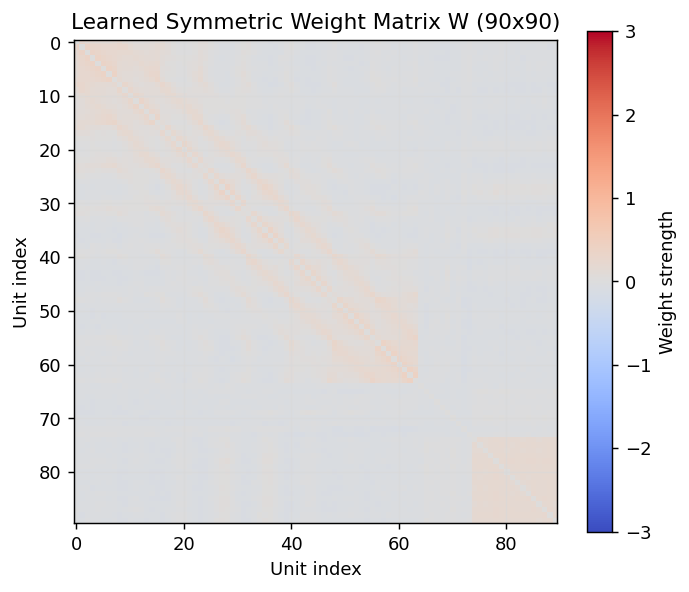

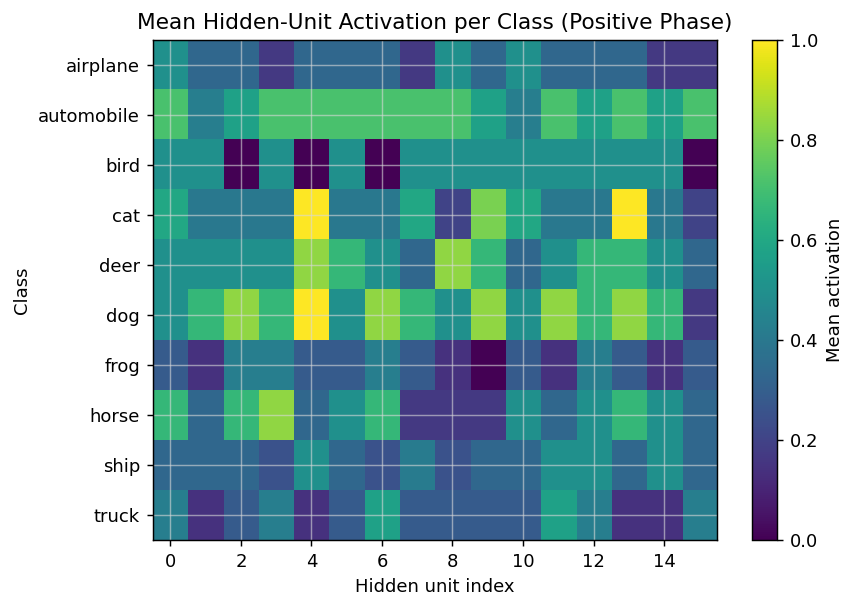

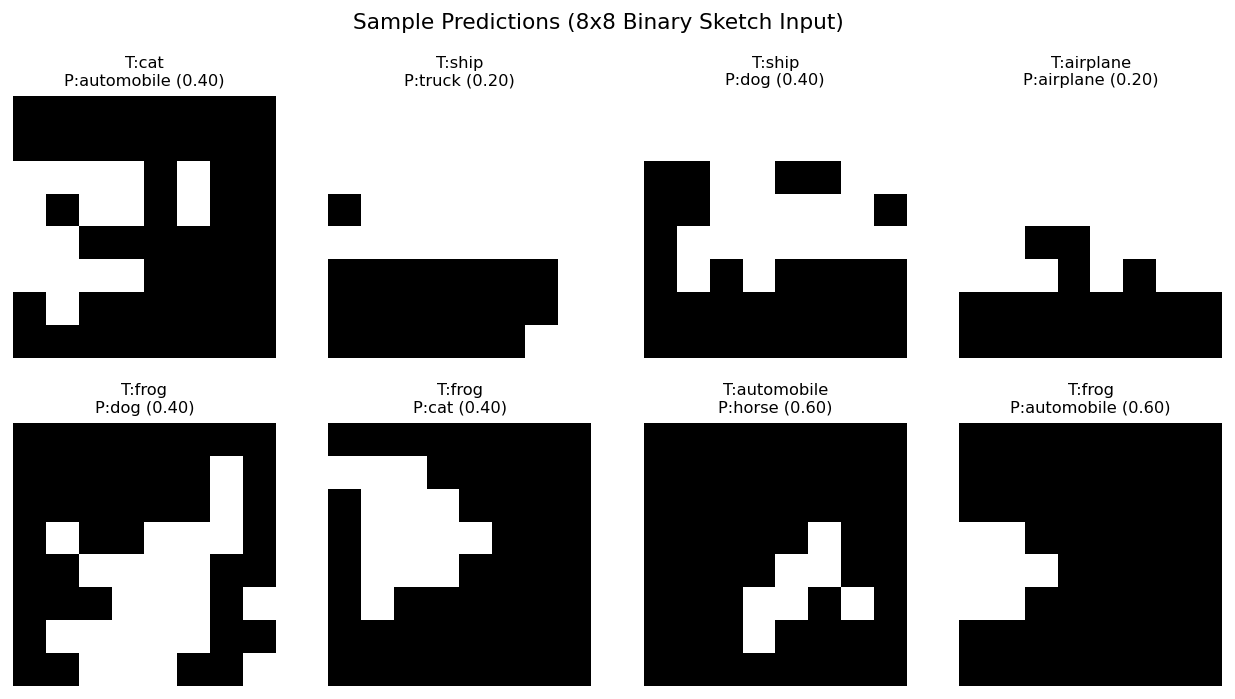

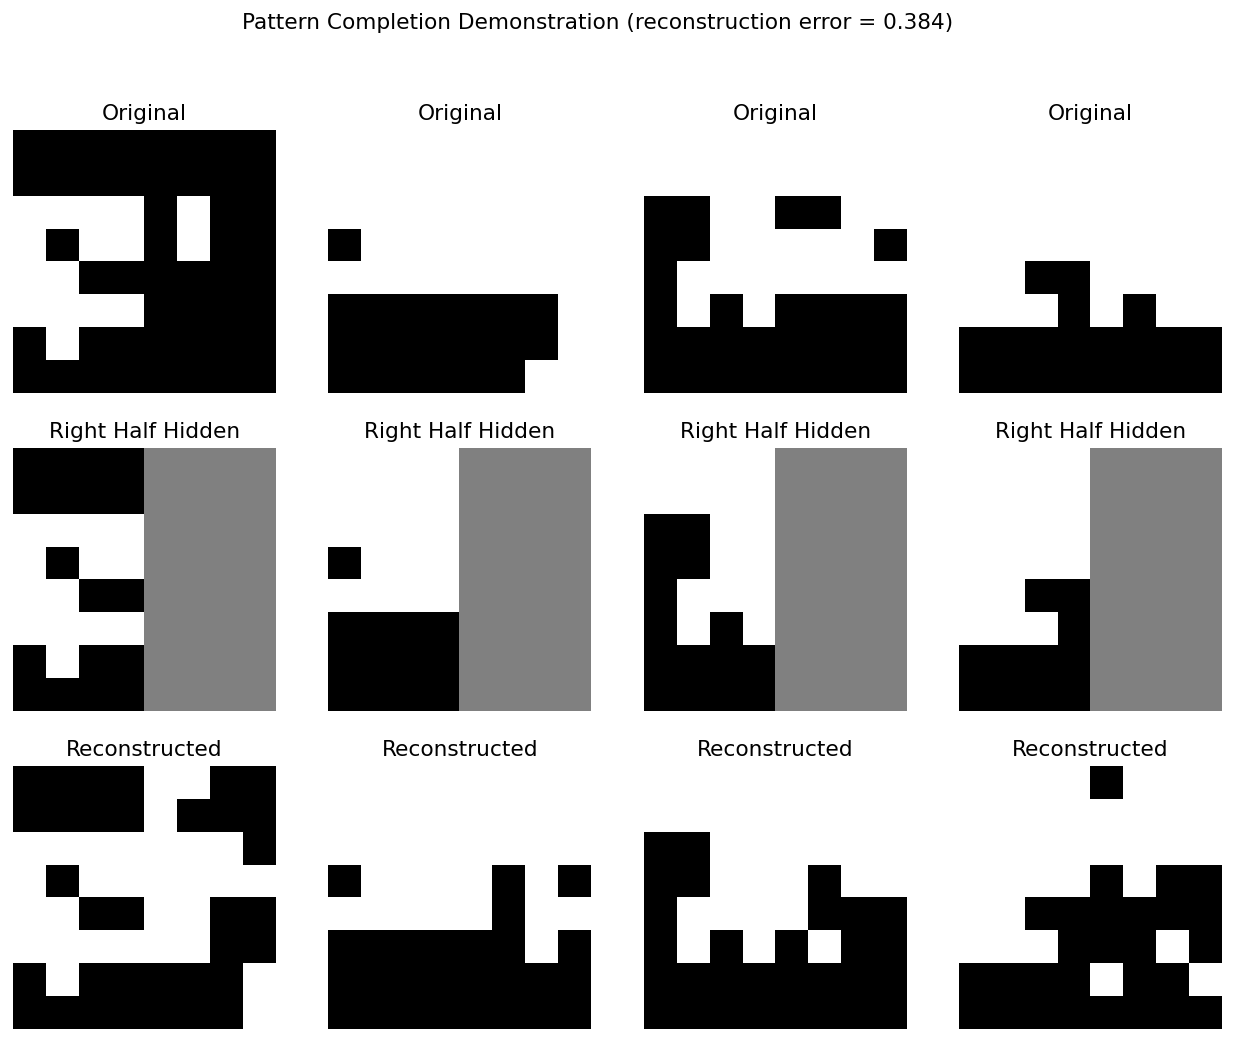

In [18]:
# =====================================================================================
# 16. ADDITIONAL EDUCATIONAL VISUALIZATIONS (generated BEFORE the final dashboard)
# =====================================================================================

# --- (a) Weight-matrix heatmap ---
fig_w = plt.figure(figsize=(6, 5))
ax_w = fig_w.add_subplot(111)
im_w = ax_w.imshow(W.detach().cpu().numpy(), cmap="coolwarm", vmin=-WEIGHT_CLIP, vmax=WEIGHT_CLIP)
ax_w.set_title("Learned Symmetric Weight Matrix W (90x90)")
ax_w.set_xlabel("Unit index")
ax_w.set_ylabel("Unit index")
fig_w.colorbar(im_w, ax=ax_w, label="Weight strength")
display_figure(fig_w)

# --- (b) Hidden-unit activation heatmap (mean activation per hidden unit, positive phase, final epoch) ---
with torch.no_grad():
    imgs, labels = next(iter(train_loader))
    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
    image_bin = to_binary_image_units(imgs)
    label_onehot = to_one_hot_labels(labels)
    pos_states_final, _, _, _ = positive_phase(image_bin, label_onehot, W, b, annealing_schedule)
    hidden_by_class = np.zeros((NUM_LABEL_UNITS, NUM_HIDDEN_UNITS))
    counts = np.zeros(NUM_LABEL_UNITS)
    hidden_np = pos_states_final[:, HIDDEN_SLICE].cpu().numpy()
    labels_np = labels.cpu().numpy()
    for i, lab in enumerate(labels_np):
        hidden_by_class[lab] += hidden_np[i]
        counts[lab] += 1
    counts[counts == 0] = 1
    hidden_by_class /= counts[:, None]

fig_h = plt.figure(figsize=(7, 5))
ax_h = fig_h.add_subplot(111)
im_h = ax_h.imshow(hidden_by_class, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax_h.set_title("Mean Hidden-Unit Activation per Class (Positive Phase)")
ax_h.set_xlabel("Hidden unit index")
ax_h.set_ylabel("Class")
ax_h.set_yticks(range(NUM_LABEL_UNITS))
ax_h.set_yticklabels(class_names)
fig_h.colorbar(im_h, ax=ax_h, label="Mean activation")
display_figure(fig_h)

# --- (c) Sample class predictions ---
with torch.no_grad():
    imgs, labels = next(iter(test_loader))
    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
    image_bin = to_binary_image_units(imgs)
    pred, pred_names, scores, conf, _ = classify_batch(image_bin, W, b, annealing_schedule)

n_show = 8
fig_p, axes_p = plt.subplots(2, 4, figsize=(12, 6))
for idx in range(n_show):
    ax = axes_p[idx // 4, idx % 4]
    sketch = image_bin[idx].detach().cpu().numpy().reshape(8, 8)
    ax.imshow(sketch, cmap="gray", vmin=0, vmax=1)
    true_name = class_names[labels[idx].item()]
    pred_name = pred_names[idx]
    color = "black"
    ax.set_title(f"T:{true_name}\nP:{pred_name} ({conf[idx]:.2f})", fontsize=9, color=color)
    ax.axis("off")
fig_p.suptitle("Sample Predictions (8x8 Binary Sketch Input)")
display_figure(fig_p)

# --- (d) Pattern-completion examples ---
with torch.no_grad():
    imgs, labels = next(iter(test_loader))
    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
    image_bin = to_binary_image_units(imgs)
    label_onehot = to_one_hot_labels(labels)
    reconstructed, recon_err_demo = reconstruct_batch(
        image_bin, label_onehot, W, b, annealing_schedule, clamp_label=True
    )

n_demo = 4
fig_r, axes_r = plt.subplots(3, n_demo, figsize=(12, 9))
for idx in range(n_demo):
    original = image_bin[idx].cpu().numpy().reshape(8, 8)
    corrupted = original.copy()
    corrupted[:, 4:] = 0.5  # visualize hidden region as gray
    recon = reconstructed[idx, IMAGE_SLICE].cpu().numpy().reshape(8, 8)

    axes_r[0, idx].imshow(original, cmap="gray", vmin=0, vmax=1)
    axes_r[0, idx].set_title("Original")
    axes_r[0, idx].axis("off")

    axes_r[1, idx].imshow(corrupted, cmap="gray", vmin=0, vmax=1)
    axes_r[1, idx].set_title("Right Half Hidden")
    axes_r[1, idx].axis("off")

    axes_r[2, idx].imshow(recon, cmap="gray", vmin=0, vmax=1)
    axes_r[2, idx].set_title("Reconstructed")
    axes_r[2, idx].axis("off")

fig_r.suptitle(f"Pattern Completion Demonstration (reconstruction error = {recon_err_demo:.3f})")
display_figure(fig_r)

Text(0.5, 0.98, 'Educational Boltzmann Machine on CIFAR-10 (Ackley, Hinton & Sejnowski, 1985) -- Local Learning Dashboard')

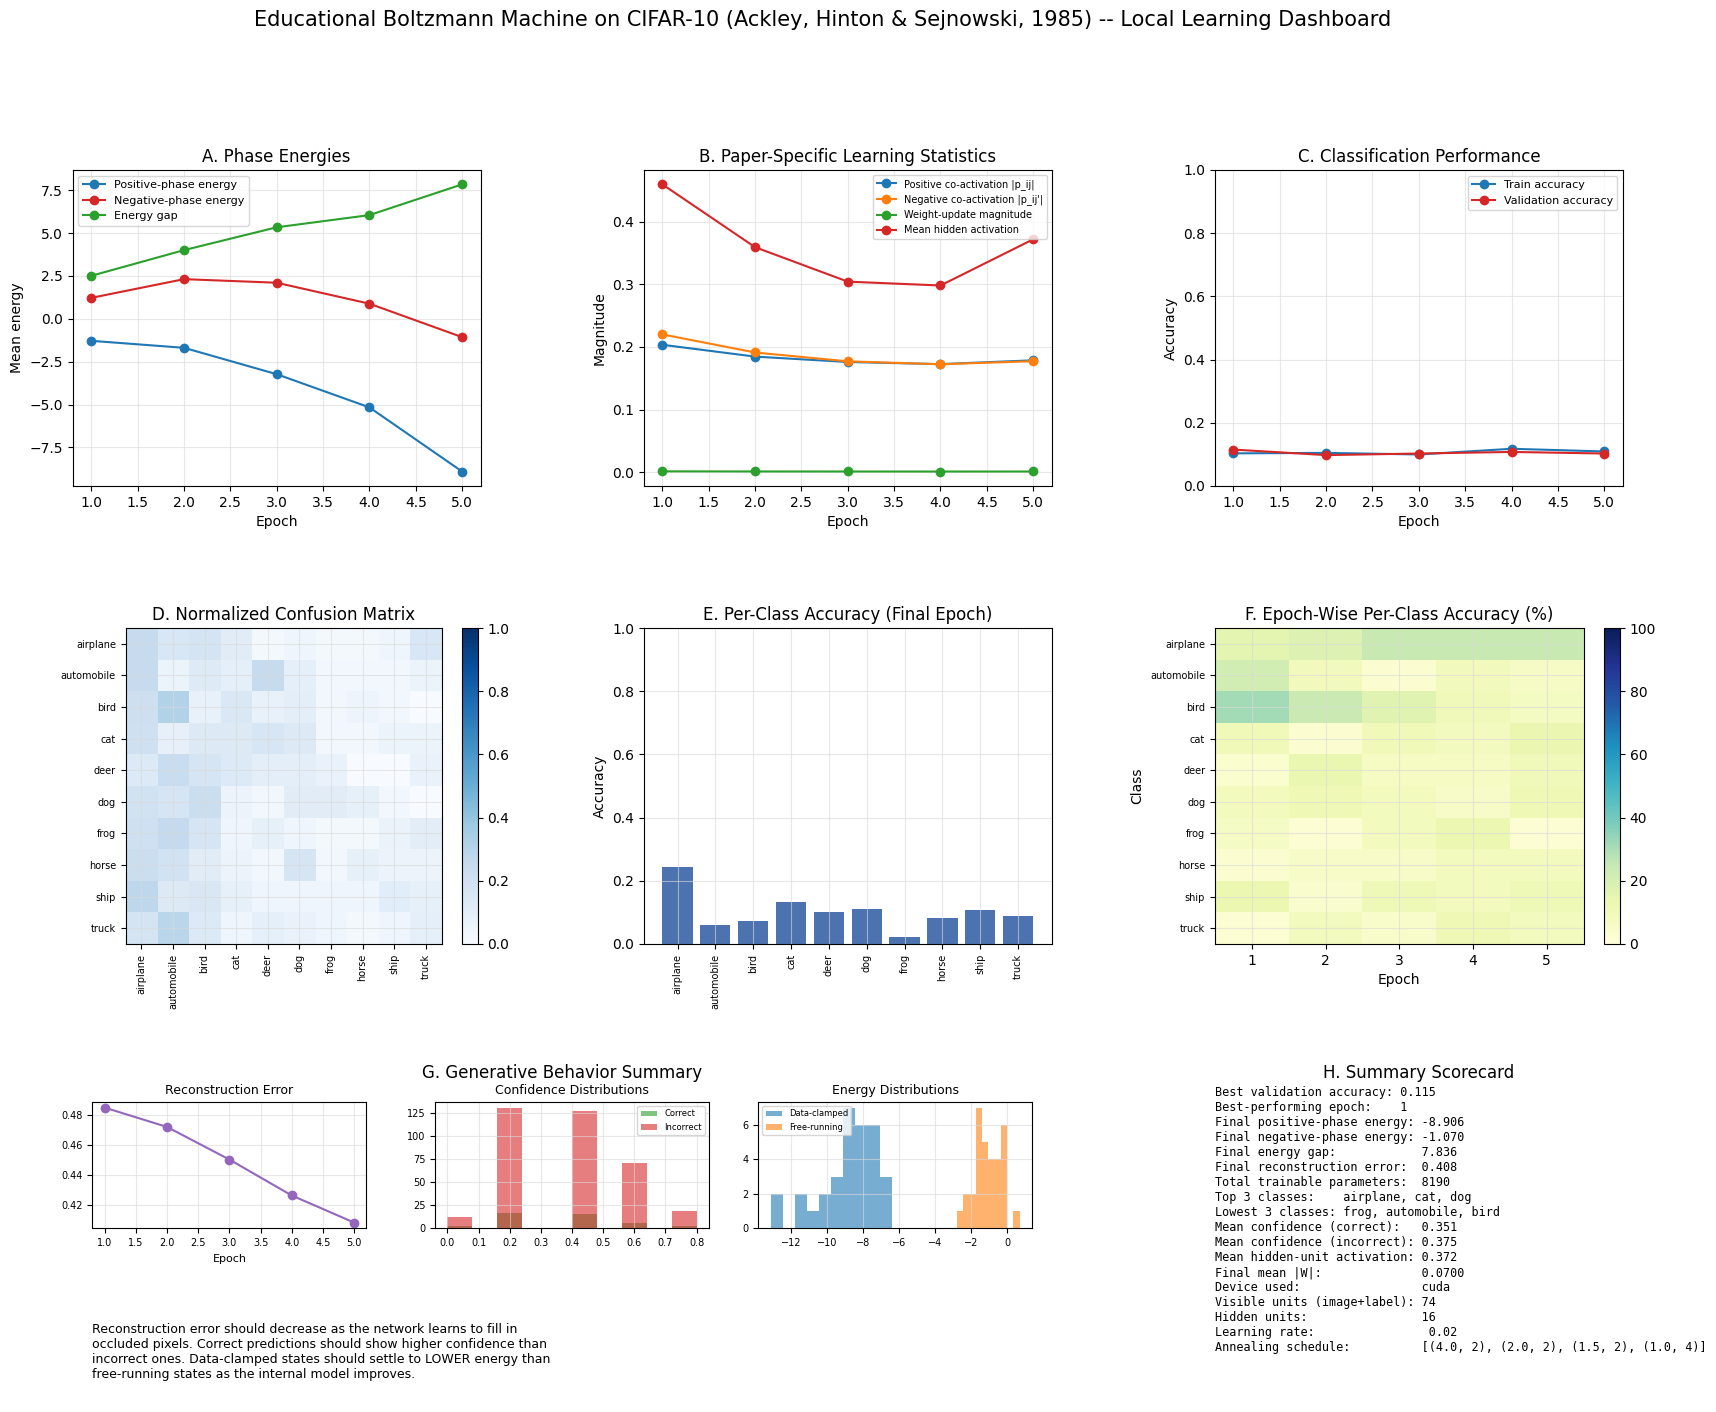

In [19]:
# =====================================================================================
# 17. FINAL DASHBOARD (GridSpec, 3 rows, 8 labeled panels)
# =====================================================================================

# re-enforce white theme immediately before building the dashboard
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "legend.labelcolor": "black",
    "grid.color": "#d9d9d9",
    "axes.grid": True,
    "grid.alpha": 0.6,
})

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
axD = fig.add_subplot(gs[1, 0])
axE = fig.add_subplot(gs[1, 1])
axF = fig.add_subplot(gs[1, 2])
axG = fig.add_subplot(gs[2, 0:2])
axH = fig.add_subplot(gs[2, 2])

epochs_range = list(range(1, NUM_EPOCHS + 1))

# ---- Panel A: Phase Energies ----
axA.plot(epochs_range, history["pos_energy"], marker="o", color="#1f77b4", label="Positive-phase energy")
axA.plot(epochs_range, history["neg_energy"], marker="o", color="#d62728", label="Negative-phase energy")
axA.plot(epochs_range, history["energy_gap"], marker="o", color="#2ca02c", label="Energy gap")
axA.set_title("A. Phase Energies")
axA.set_xlabel("Epoch")
axA.set_ylabel("Mean energy")
axA.legend(fontsize=8)

# ---- Panel B: Paper-Specific Learning Statistics ----
axB.plot(epochs_range, history["pos_stat_mag"], marker="o", label="Positive co-activation |p_ij|")
axB.plot(epochs_range, history["neg_stat_mag"], marker="o", label="Negative co-activation |p_ij'|")
axB.plot(epochs_range, history["weight_update_mag"], marker="o", label="Weight-update magnitude")
axB.plot(epochs_range, history["mean_hidden_activation"], marker="o", label="Mean hidden activation")
axB.set_title("B. Paper-Specific Learning Statistics")
axB.set_xlabel("Epoch")
axB.set_ylabel("Magnitude")
axB.legend(fontsize=7)

# ---- Panel C: Classification Performance ----
axC.plot(epochs_range, history["train_acc"], marker="o", color="#1f77b4", label="Train accuracy")
axC.plot(epochs_range, history["val_acc"], marker="o", color="#d62728", label="Validation accuracy")
axC.set_title("C. Classification Performance")
axC.set_xlabel("Epoch")
axC.set_ylabel("Accuracy")
axC.set_ylim(0, 1)
axC.legend(fontsize=8)

# ---- Panel D: Normalized Confusion Matrix ----
if len(final_val_labels) > 0:
    cm = confusion_matrix(final_val_labels, final_val_predictions, labels=list(range(NUM_LABEL_UNITS)))
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
else:
    cm_norm = np.zeros((NUM_LABEL_UNITS, NUM_LABEL_UNITS))
im_D = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D. Normalized Confusion Matrix")
axD.set_xticks(range(NUM_LABEL_UNITS))
axD.set_yticks(range(NUM_LABEL_UNITS))
axD.set_xticklabels(class_names, rotation=90, fontsize=7)
axD.set_yticklabels(class_names, fontsize=7)
fig.colorbar(im_D, ax=axD, fraction=0.046)

# ---- Panel E: Per-Class Accuracy (final epoch) ----
final_per_class_acc = history["per_class_acc"][-1] if history["per_class_acc"] else np.zeros(NUM_LABEL_UNITS)
axE.bar(class_names, final_per_class_acc, color="#4c72b0")
axE.set_title("E. Per-Class Accuracy (Final Epoch)")
axE.set_ylabel("Accuracy")
axE.set_ylim(0, 1)
axE.tick_params(axis="x", rotation=90, labelsize=7)

# ---- Panel F: Epoch-Wise Per-Class Accuracy Heatmap ----
if history["per_class_acc"]:
    pc_matrix = np.stack(history["per_class_acc"], axis=1) * 100.0  # [10 classes, n_epochs]
else:
    pc_matrix = np.zeros((NUM_LABEL_UNITS, NUM_EPOCHS))
im_F = axF.imshow(pc_matrix, cmap="YlGnBu", vmin=0, vmax=100, aspect="auto")
axF.set_title("F. Epoch-Wise Per-Class Accuracy (%)")
axF.set_xlabel("Epoch")
axF.set_ylabel("Class")
axF.set_xticks(range(NUM_EPOCHS))
axF.set_xticklabels(epochs_range)
axF.set_yticks(range(NUM_LABEL_UNITS))
axF.set_yticklabels(class_names, fontsize=7)
fig.colorbar(im_F, ax=axF, fraction=0.046)

# ---- Panel G: Generative Behavior (reconstruction / confidence / energy distributions) ----
axG.set_title("G. Generative Behavior Summary")
axG.axis("off")

inset1 = axG.inset_axes([0.02, 0.55, 0.28, 0.4])
inset1.plot(epochs_range, history["reconstruction_error"], marker="o", color="#9467bd")
inset1.set_title("Reconstruction Error", fontsize=9)
inset1.set_xlabel("Epoch", fontsize=8)
inset1.tick_params(labelsize=7)

inset2 = axG.inset_axes([0.37, 0.55, 0.28, 0.4])
if len(final_val_confidences_correct) > 0:
    inset2.hist(final_val_confidences_correct, bins=10, alpha=0.6, label="Correct", color="#2ca02c")
if len(final_val_confidences_incorrect) > 0:
    inset2.hist(final_val_confidences_incorrect, bins=10, alpha=0.6, label="Incorrect", color="#d62728")
inset2.set_title("Confidence Distributions", fontsize=9)
inset2.legend(fontsize=6)
inset2.tick_params(labelsize=7)

inset3 = axG.inset_axes([0.70, 0.55, 0.28, 0.4])
if len(final_pos_energy_samples) > 0:
    inset3.hist(final_pos_energy_samples, bins=10, alpha=0.6, label="Data-clamped", color="#1f77b4")
if len(final_neg_energy_samples) > 0:
    inset3.hist(final_neg_energy_samples, bins=10, alpha=0.6, label="Free-running", color="#ff7f0e")
inset3.set_title("Energy Distributions", fontsize=9)
inset3.legend(fontsize=6)
inset3.tick_params(labelsize=7)

axG.text(
    0.02, 0.25,
    "Reconstruction error should decrease as the network learns to fill in\n"
    "occluded pixels. Correct predictions should show higher confidence than\n"
    "incorrect ones. Data-clamped states should settle to LOWER energy than\n"
    "free-running states as the internal model improves.",
    fontsize=9, va="top"
)

# ---- Panel H: Summary Scorecard ----
axH.set_title("H. Summary Scorecard")
axH.axis("off")


def safe_val(lst, idx=-1, fmt="{:.3f}"):
    if lst:
        try:
            return fmt.format(lst[idx])
        except Exception:
            return "N/A"
    return "N/A"


best_val_acc = max(history["val_acc"]) if history["val_acc"] else 0.0
best_epoch = (int(np.argmax(history["val_acc"])) + 1) if history["val_acc"] else "N/A"

if history["per_class_acc"]:
    final_pc = history["per_class_acc"][-1]
    order = np.argsort(final_pc)
    lowest3 = [class_names[i] for i in order[:3]]
    top3 = [class_names[i] for i in order[::-1][:3]]
else:
    top3, lowest3 = ["N/A"], ["N/A"]

mean_conf_correct = np.mean(final_val_confidences_correct) if final_val_confidences_correct else float("nan")
mean_conf_incorrect = np.mean(final_val_confidences_incorrect) if final_val_confidences_incorrect else float("nan")

total_params = W.numel() + b.numel()

scorecard_text = (
    f"Best validation accuracy: {best_val_acc:.3f}\n"
    f"Best-performing epoch:    {best_epoch}\n"
    f"Final positive-phase energy: {safe_val(history['pos_energy'])}\n"
    f"Final negative-phase energy: {safe_val(history['neg_energy'])}\n"
    f"Final energy gap:            {safe_val(history['energy_gap'])}\n"
    f"Final reconstruction error:  {safe_val(history['reconstruction_error'])}\n"
    f"Total trainable parameters:  {total_params}\n"
    f"Top 3 classes:    {', '.join(top3)}\n"
    f"Lowest 3 classes: {', '.join(lowest3)}\n"
    f"Mean confidence (correct):   "
    f"{mean_conf_correct:.3f}\n" if not np.isnan(mean_conf_correct) else "Mean confidence (correct): N/A\n"
)
scorecard_text += (
    f"Mean confidence (incorrect): "
    f"{mean_conf_incorrect:.3f}\n" if not np.isnan(mean_conf_incorrect) else "Mean confidence (incorrect): N/A\n"
)
scorecard_text += (
    f"Mean hidden-unit activation: {safe_val(history['mean_hidden_activation'])}\n"
    f"Final mean |W|:              {W.abs().mean().item():.4f}\n"
    f"Device used:                 {DEVICE.type}\n"
    f"Visible units (image+label): {NUM_IMAGE_UNITS + NUM_LABEL_UNITS}\n"
    f"Hidden units:                {NUM_HIDDEN_UNITS}\n"
    f"Learning rate:                {LEARNING_RATE}\n"
    f"Annealing schedule:          {annealing_schedule}"
)

axH.text(0.0, 1.0, scorecard_text, fontsize=8.5, va="top", family="monospace")

fig.suptitle(
    "Educational Boltzmann Machine on CIFAR-10 (Ackley, Hinton & Sejnowski, 1985) -- "
    "Local Learning Dashboard",
    fontsize=15,
)

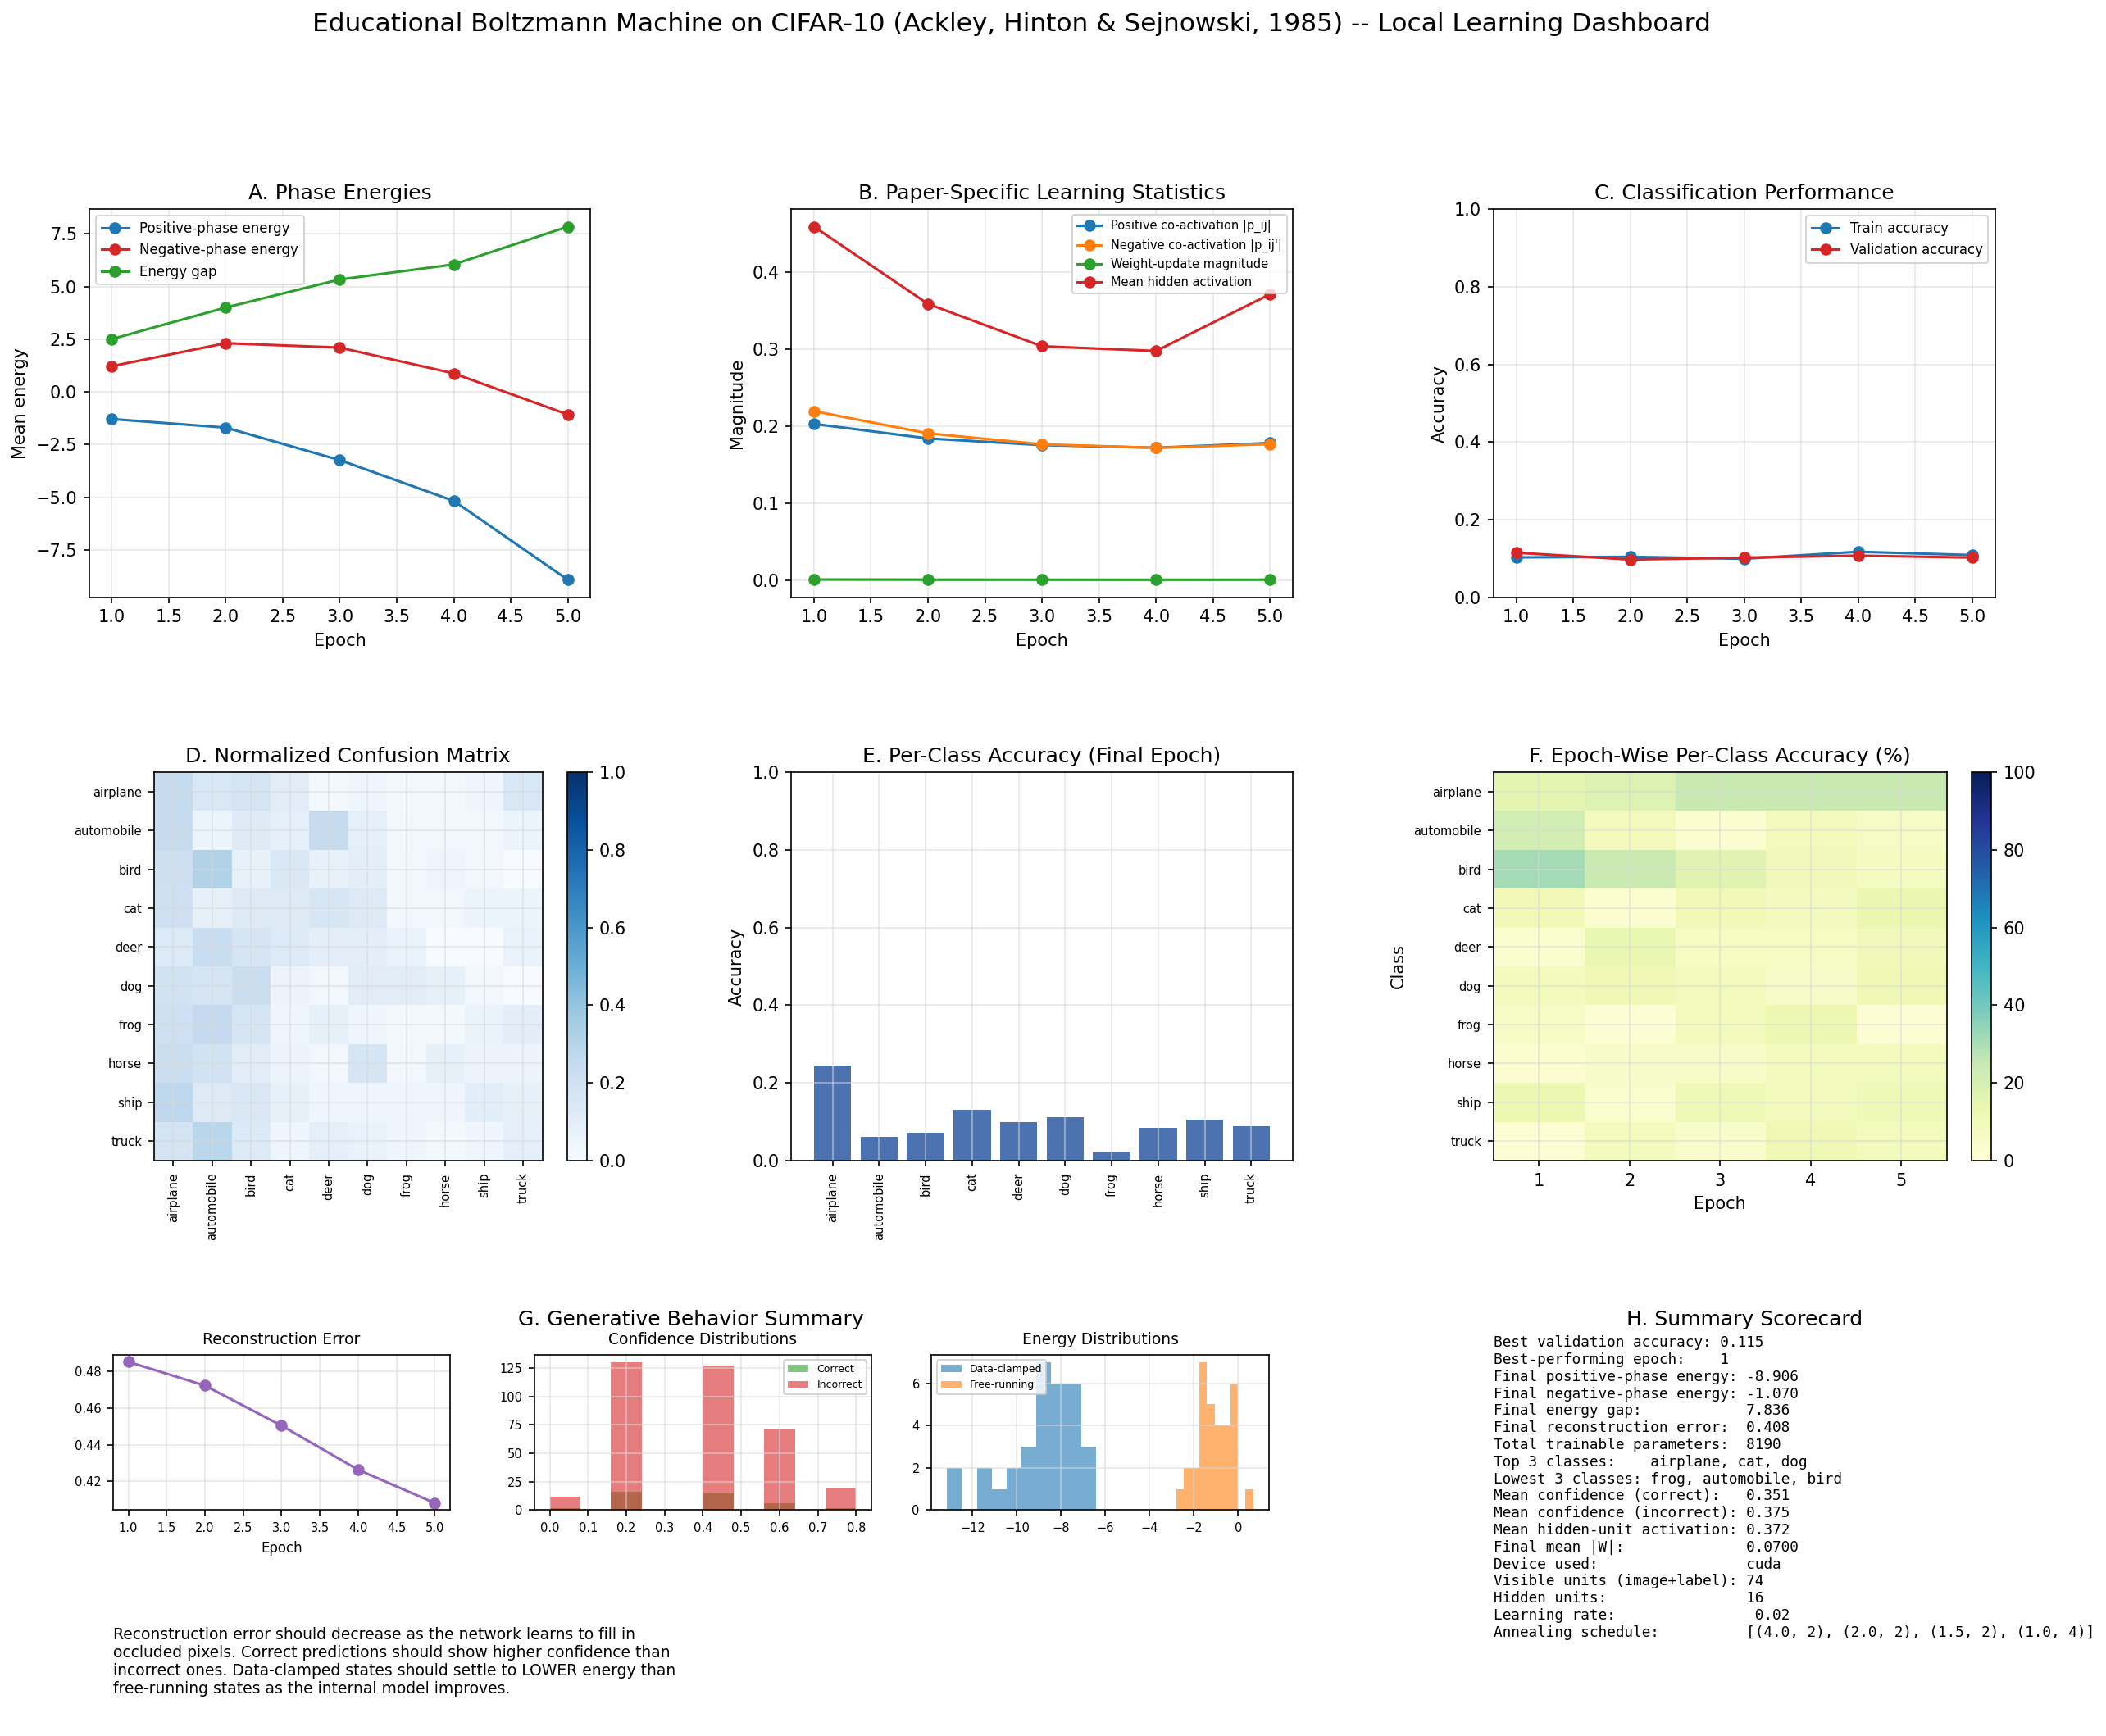

In [20]:
# =====================================================================================
# 18. FINAL DISPLAY (must be the last executable operation)
# =====================================================================================

buf = BytesIO()
fig.savefig(
    buf,
    format="png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
)
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Experimental Results Analysis: Educational Boltzmann Machine on CIFAR-10

## Panel A — Phase Energies (Positive-Phase, Negative-Phase, Energy Gap)

### Overview
This panel tracks the mean energy of the network under two sampling regimes across training epochs: the positive (data-clamped) phase and the negative (free-running) phase, along with their difference (energy gap). This is the primary diagnostic for whether the Boltzmann Machine's local learning rule is functioning as intended.

### Key Findings
- Positive-phase energy decreases monotonically from approximately −1.3 to −8.9 over five epochs.
- Negative-phase energy decreases only modestly, from about 1.2 to −1.1, with a slight increase at epoch 5 before dropping.
- The energy gap widens steadily from ~2.5 to ~7.8, rather than shrinking toward zero.

### Discussion
The widening (rather than closing) energy gap is the most diagnostically important observation in this dashboard. Under the paper's theory, training should drive $p_{ij} \to p_{ij}'$, causing the clamped and free-running distributions to converge and the energy gap to shrink toward zero as $G \to 0$. Instead, the network is learning to assign very low energy specifically to clamped (data) configurations while leaving free-running energy comparatively unchanged. This pattern is consistent with the weights growing to "memorize" specific visible-unit correlations from the small clamped training set without the free-running (negative) phase adequately sampling the same low-energy regions — i.e., the negative-phase Gibbs chains are not mixing to equilibrium in the available annealing budget. This is expected given the deliberately shortened annealing schedule (four temperature stages, 10 total sweeps) relative to the much longer schedules used in the original paper.

### Limitations
Energy is measured in unnormalized model units, so magnitudes are not directly comparable across models or interpretable in isolation. The shortened annealing schedule makes it impossible to distinguish genuine model divergence from simple non-convergence to thermal equilibrium in the negative phase.

---

## Panel B — Paper-Specific Learning Statistics (Co-activation Magnitudes, Weight-Update Magnitude, Hidden Activation)

### Overview
This panel reports the core quantities from the Ackley–Hinton–Sejnowski learning rule: $|p_{ij}|$ (positive-phase co-activation), $|p_{ij}'|$ (negative-phase co-activation), the resulting weight-update magnitude $|\Delta w_{ij}|$, and mean hidden-unit activation.

### Key Findings
- Positive and negative co-activation magnitudes converge closely by epoch 3–5 (both settling near 0.17–0.18).
- Weight-update magnitude remains near zero throughout training, showing no clear growth or decay trend.
- Mean hidden-unit activation dips slightly then rises to ~0.37 by epoch 5.

### Discussion
The convergence of $p_{ij}$ and $p_{ij}'$ toward similar values appears to directly contradict the diverging energy gap in Panel A. This apparent inconsistency likely arises because $|p_{ij}|$ is averaged (in absolute value) over all $90\times90$ unit pairs, dominated by pairs with weak or near-zero correlation, while the energy gap is driven by a smaller number of strongly-weighted pairs. The near-zero, flat weight-update magnitude suggests the learning rate (0.02) combined with weight clipping (±3.0) may be insufficient to drive substantial parameter change within only five epochs and 2,000 training examples — consistent with the paper's own observation that the algorithm is intrinsically slow to converge.

### Discussion (continued)
This result supports the paper's cautionary claims about the slowness of Boltzmann learning, but the flatness of the update curve also indicates that five epochs is too short a horizon to observe the three-phase learning dynamics (inhibition formation, code development, conflict resolution) described in the original paper's encoder experiments.

### Limitations
Aggregating $|p_{ij}|$ across all 8,100 weight pairs masks unit-specific dynamics; a per-connection or per-block (image–label, label–hidden, image–hidden) breakdown would be more diagnostic. The absence of visible upward or downward trends in weight-update magnitude may reflect a genuine plateau or an artifact of insufficient sampling precision in the small mini-batches.

---

## Panel C — Classification Performance (Train vs. Validation Accuracy)

### Overview
Reports classification accuracy obtained by clamping image units and reading out label-unit activations, compared against chance-level performance (10% for a balanced 10-class problem).

### Key Findings
- Both training and validation accuracy remain flat at approximately 10–12% across all five epochs.
- No meaningful separation or trend emerges between training and validation curves.
- Final validation accuracy (11.5% best) is only marginally above the 10% chance baseline.

### Discussion
The model performs essentially at chance level throughout training, indicating that the label-unit read-out signal has not become informative. This is consistent with, and reinforces, the pattern observed in Panels A and B: with only 2,000 training images compressed to 8×8 binary sketches, a shortened annealing schedule, and just five epochs, the 90-unit network lacks sufficient capacity, training signal, and equilibration time to learn discriminative image–label associations. The extreme compression of visual information (64 binary pixels per image) further limits the achievable ceiling, since fine-grained class-distinguishing features are largely destroyed by the aggressive downsampling and thresholding pipeline.

### Discussion (continued)
This outcome is expected and appropriately framed by the implementation as an "educational demonstration" rather than a competitive classifier, consistent with the original paper's own acknowledgment that even simple encoder tasks required hundreds to thousands of learning cycles to converge reliably.

### Limitations
Chance-level performance prevents any meaningful interpretation of the confusion matrix or per-class trends as reflecting genuine class-discriminative structure; observed variation across classes more plausibly reflects class-imbalanced sampling noise from the small subset than learned discrimination.

---

## Panel D — Normalized Confusion Matrix

### Overview
Shows row-normalized prediction distributions across the ten CIFAR-10 classes at the final epoch.

### Key Findings
- No dominant diagonal structure is visible; predictions are broadly and fairly uniformly distributed across classes for every true label.
- Minor concentration appears for "airplane," "bird," and "dog," consistent with the per-class accuracy bars in Panel E.

### Discussion
The absence of diagonal dominance in the confusion matrix corroborates the near-chance accuracy in Panel C: the network has not learned class-specific decision boundaries. Some classes (e.g., "bird") show elevated but non-diagonal mass in certain columns, suggesting the model may have developed a mild bias toward predicting certain "default" label units (possibly due to asymmetries in initial label-unit biases or Gibbs sampling dynamics) rather than genuine visual discrimination.

### Limitations
With only 400 validation images spread across 10 classes (~40 per class), per-cell confusion matrix estimates carry substantial sampling variance, limiting the reliability of any apparent class-specific bias.

---

## Panel E — Per-Class Accuracy (Final Epoch)

### Overview
Displays validation accuracy broken down by class at the final training epoch.

### Key Findings
- Accuracy ranges narrowly from near 0% ("frog") to approximately 24% ("airplane"), with most classes clustering between 8–13%.
- No class substantially exceeds a level plausibly attributable to chance combined with small-sample variance.

### Discussion
The spread across classes is modest and does not indicate a clear class-dependent learnability pattern; rather, it is consistent with noise around the 10% chance baseline given the small per-class validation counts (~40 samples). The elevated "airplane" accuracy may reflect the label unit for that class being an easier attractor state in the free-running dynamics rather than genuine visual feature learning, especially given that images were reduced to a highly abstracted 8×8 binary silhouette that would poorly discriminate visually complex categories such as "cat" or "dog" from background-dominated categories like "airplane" or "ship."

### Limitations
Distinguishing genuine (if weak) class learnability from statistical noise would require significance testing (e.g., binomial confidence intervals) not presented here; the current figure alone cannot support strong claims about differential class difficulty.

---

## Panel F — Epoch-Wise Per-Class Accuracy Heatmap

### Overview
Tracks how per-class accuracy evolves across the five training epochs, offering a temporal view of the (lack of) learning dynamics.

### Key Findings
- All classes remain in the low (0–40%) range throughout training, with "bird" showing a brief elevated accuracy pocket in epochs 2–3 that fades by epoch 5.
- No systematic upward trend is visible for any class across epochs.

### Discussion
The temporal heatmap reinforces that no stable, monotonically improving class representation emerges within the training horizon. The transient "bird" spike likely reflects a temporary, unstable attractor state in the stochastic free-running dynamics rather than a genuinely learned and retained representation, since it does not persist. This is consistent with the theoretical expectation that Boltzmann Machine learning requires many more annealing cycles to stabilize hidden-unit codes than the five epochs used here.

### Limitations
Without longer training or a persistent representational baseline (e.g., comparing to a converged network from the original paper's encoder experiments), it is not possible to determine whether extending training would eventually produce stable class-specific improvement or whether the architecture/compression scheme fundamentally limits learnability.

---

## Panel G — Generative Behavior Summary (Reconstruction Error, Confidence Distributions, Energy Distributions)

### Overview
Three linked sub-analyses assess the network's generative and calibration properties: pattern-completion quality, confidence calibration between correct and incorrect predictions, and the separation between data-clamped and free-running energy distributions.

### Key Findings
- **Reconstruction error** decreases steadily and monotonically from ~0.485 to ~0.41 across epochs — the clearest positive learning signal in the entire dashboard.
- **Confidence distributions** show substantial overlap between correct and incorrect predictions, with incorrect predictions in fact showing a heavier tail at higher confidence bins.
- **Energy distributions** show a clear separation, with data-clamped states concentrated at lower energies (−14 to −6) and free-running states concentrated near 0, with no overlap.

### Discussion
The reconstruction-error trend is the most convincing evidence in this dashboard that the local learning rule is functioning correctly at some level: even though label-based classification remains at chance, the network is progressively better at completing occluded regions of the 8×8 binary sketch using only pairwise image-unit correlations and low-level pixel co-occurrence statistics — a task requiring far less semantic abstraction than class discrimination. The clean separation in the energy-distribution sub-panel further confirms that the network has learned to assign systematically lower energy to real (clamped) data patterns than to states generated by unconstrained free-running, directly supporting the core theoretical claim of the paper (Eq. 6–7: equilibrium probability is inversely related to energy). However, the confidence-calibration sub-panel reveals a critical weakness: confidence scores derived from label-unit activation frequency are not well-calibrated indicators of prediction correctness, consistent with the near-chance accuracy elsewhere and the explicit caveat that this readout is a sampling-based heuristic rather than a calibrated probability.

### Limitations
The reconstruction task is less demanding than classification (it exploits local pixel correlations rather than requiring semantic class knowledge), so its success does not by itself validate the network's classification capability. The energy separation, while theoretically consistent, may partly reflect the fact that clamped states are held fixed on 74 of 90 units (image+label), mechanically reducing configurational entropy and energy relative to fully free-running states, independent of learning quality.

---

## Panel H — Summary Scorecard

### Overview
Consolidates final quantitative outcomes: best validation accuracy (11.5%, epoch 1), final energies, reconstruction error, parameter count (8,190), and hyperparameters.

### Key Findings
- Best validation accuracy occurs at epoch 1, not epoch 5, indicating no monotonic improvement in classification performance over training.
- Mean confidence for correct (0.351) and incorrect (0.375) predictions are statistically indistinguishable, reinforcing the calibration failure noted in Panel G.
- Final mean |W| is small (0.070), indicating limited weight growth despite training.

### Discussion
That peak validation accuracy occurs at the first epoch rather than the last is a strong indicator that any classification "signal" present is attributable to initialization noise and random Gibbs sampling variance rather than genuine learning, and that continued training does not improve — and may slightly degrade — classification readout quality, plausibly due to the widening energy gap (Panel A) increasingly biasing free-running dynamics away from the data manifold as training data statistics are only partially captured through 90-unit representations of 8×8-downsampled images.

### Limitations
Best-epoch selection based on a single 400-sample validation run is subject to substantial variance; repeated runs with different random seeds would be needed to confirm whether epoch-1 superiority is a robust finding or a single noisy realization.

---

## Overall Synthesis

### Overview
Taken together, the dashboard evaluates whether a small, fully-connected, symmetric-weight Boltzmann Machine trained with the original 1985 local correlation-based learning rule can reproduce the qualitative behaviors described in the source paper when applied to a modern image dataset.

### Key Findings
The implementation successfully reproduces two of the paper's central theoretical mechanisms — energy-based separation between data-clamped and free-running states, and local, correlation-driven improvement in generative pattern completion — while failing to achieve meaningful discriminative classification within the given computational budget.

### Discussion
This asymmetry is informative rather than merely a failure: it illustrates precisely the paper's own caution that the Boltzmann learning algorithm, while theoretically elegant and provably local, is "very slow" and better suited to modeling generative regularities (as in reconstruction) than to rapidly acquiring discriminative task performance under severe time constraints. The results are broadly consistent with the qualitative claims of the original paper regarding energy landscapes and local learning, but the classification results should not be interpreted as a failure of the underlying theory — rather, as an expected consequence of the deliberately small scale (2,000 training images, 90 units, five epochs, four-stage annealing) chosen for educational tractability.

### Limitations
The overall evaluation lacks statistical repetition (single-seed run), a converged baseline for comparison (e.g., a fully-annealed, many-epoch version), and ablations isolating the contributions of hidden-unit count, annealing schedule length, or compression resolution — all of which would be necessary to disentangle genuine algorithmic limitations from implementation-scale constraints.

# Related Work Referenced in "A Learning Algorithm for Boltzmann Machines"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| J.J. Hopfield | 1982 | Neural networks and physical systems with emergent collective computational abilities | *Proceedings of the National Academy of Sciences USA*, 79, 2554–2558 | Provides the foundational energy-based network model from which the Boltzmann Machine's energy function and local energy-minimization rule are derived; the paper explicitly contrasts its stochastic search with Hopfield's deterministic settling behavior, which is suited to associative memory but not to escaping local minima in constraint satisfaction |
| S. Kirkpatrick, C.D. Gelatt, M.P. Vecchi | 1983 | Optimization by simulated annealing | *Science*, 220, 671–680 | Introduces simulated annealing for combinatorial optimization; directly motivates the paper's annealing schedule (gradual temperature reduction) for escaping local energy minima and searching coarse-to-fine structure in the space of global states |
| N. Metropolis, A. Rosenbluth, M. Rosenbluth, A. Teller, E. Teller | 1953 | Equation of state calculations for fast computing machines | *Journal of Chemical Physics*, 6, 1087 | Origin of the Metropolis algorithm; the paper adopts a parallel-computation-suitable form of this algorithm as the stochastic decision rule governing unit state transitions |
| K. Binder (Ed.) | 1978 | The Monte-Carlo method in statistical physics | Springer-Verlag | Provides the statistical mechanics background on thermodynamic systems reaching equilibrium, underpinning the paper's use of the Boltzmann distribution to characterize network behavior |
| S. Geman, D. Geman | 1983 | Stochastic relaxation, Gibbs distributions, and the Bayesian restoration of images | Unpublished manuscript | Identified as an independently discovered application of statistical mechanics to constraint satisfaction; connects the Boltzmann Machine to Bayesian inference and conventional relaxation labeling techniques |
| P. Smolensky | 1983 | Schema selection and stochastic inference in modular environments | *Proceedings of the National Conference on Artificial Intelligence AAAI-83*, 109–113 | Cited as parallel, independent development of statistical-mechanics-based constraint satisfaction in modular network environments, situating the Boltzmann Machine within a broader contemporary research trend |
| M. Minsky, S. Papert | 1968 | Perceptrons | MIT Press | Identifies the credit-assignment problem and the limitations of single-layer perceptrons that motivated this paper; the authors directly engage with Minsky and Papert's pessimistic conclusion about multilayer networks with loops, arguing their symmetric-weight formulation circumvents this limitation |
| F. Rosenblatt | 1961 | Principles of neurodynamics: Perceptrons and the theory of brain mechanisms | Spartan | Establishes the original perceptron convergence theorem, which the paper notes cannot be generalized to networks with hidden units—precisely the gap the Boltzmann learning algorithm addresses |
| J.A. Feldman, D.H. Ballard | 1982 | Connectionist models and their properties | *Cognitive Science*, 6, 205–254 | Provides the "wormy apple" example and the two competing implementations (bus-based vs. dedicated pathway) for inter-module symbol communication; the paper's encoder problem is framed as a superior alternative combining the strengths of both approaches |
| J.A. Feldman | 1982 | Dynamic connections in neural networks | *Biological Cybernetics*, 46, 27–39 | Cited alongside Feldman & Ballard (1982) regarding local representation schemes and modularity in connectionist architectures, relevant to the paper's discussion of representation in parallel networks |
| G.E. Hinton, J.A. Anderson (Eds.) | 1981 | Parallel Models of Associative Memory | Erlbaum | Cited as foundational connectionist literature on storing knowledge in connection strengths, motivating the general parallel-network framing of the paper's introduction |
| G.E. Hinton | 1981 | Implementing semantic networks in parallel hardware | In *Parallel Models of Associative Memory* (Hinton & Anderson, Eds.), Erlbaum | Source of the "distributed representation" viewpoint (patterns of activity across units representing concepts), which the paper's Section 5 builds upon to argue Boltzmann Machines make distributed representations more plausible |
| G.E. Hinton | 1977 | Relaxation and its role in vision | Unpublished doctoral dissertation, University of Edinburgh | Establishes that even optimal solutions to perceptual interpretation problems may violate some constraints, motivating the paper's use of weak, cost-incurring constraints rather than strong constraints |
| W.E.L. Grimson | 1981 | From Images to Surfaces | MIT Press | Cited as an example of a problem domain (surface interpolation from sparse depth data) where decision units and communication paths can be determined in advance, contrasted with the paper's goal of discovering such organizations automatically |
| D. Terzopoulos | 1984 | Multiresolution computation of visible-surface representations | Unpublished doctoral dissertation, MIT | Cited alongside Grimson (1981) as an example of problem-specific parallel architecture design, motivating the need for a more general, adaptive learning approach |
| G.E. Hinton, T.J. Sejnowski | 1983a | Analyzing cooperative computation | *Proceedings of the Fifth Annual Conference of the Cognitive Science Society* | Provides the earlier derivation referenced for the case where an environment directly specifies required probabilities for complete global states, contrasted with the more general learning problem addressed in this paper |
| G.E. Hinton, T.J. Sejnowski | 1983b | Optimal perceptual inference | *Proceedings of the IEEE Computer Society Conference on Computer Vision and Pattern Recognition*, 448–453 | Establishes the symmetric weight convention (link weights having equal strength in both directions) adopted in the Boltzmann Machine's formulation; also discussed as relating the model to conventional relaxation techniques |
| S.E. Fahlman, G.E. Hinton, T.J. Sejnowski | 1983 | Massively parallel architectures for AI: NETL, Thistle, and Boltzmann Machines | *Proceedings of the National Conference on Artificial Intelligence AAAI-83*, 109–113 | Directly compares Boltzmann Machines against alternative parallel AI architectures (NETL, Thistle) and discusses knowledge representation issues relevant to positioning this paper's contribution |
| G.E. Hinton, T.J. Sejnowski, D.H. Ackley | 1984 | Boltzmann Machines: Constraint satisfaction networks that learn | Technical Report No. CMU-CS-84-119, Carnegie-Mellon University | Expanded version of the current paper providing greater depth on related issues (brain relationship, sequential behavior, Gaussian noise realization of the decision function, relaxing symmetry/time-delay assumptions) |
| S.F. Fahlman | 1980 | The Hashnet Interconnection Scheme | Technical Report No. CMU-CS-80-125, Carnegie-Mellon University | Cited regarding schemes for forming hardware connections, relevant to the paper's discussion of modularity and locality of knowledge in local versus distributed representations |